# Voltage-Stratified Data Analytics Study of Electrical Distribution Outages
## Muscat Governorate — Nama Electricity Distribution Company (NEDC) 2025

---

| | |
|---|---|
| **Student** | Ayat Saif Al Sariri |
| **Instructor** | Dr. Hamza Zidoum |
| **Course** | Data Exploration and Analysis — Sultan Qaboos University |
| **Dataset** | NEDC Muscat Master Outage Register, Jan–Dec 2025 (18,320 records) |
| **Data Access** | Formal No-Objection Letter (NOL) issued by Nama EDC |

---


*   List item
*   List item



---
# PART 1 — Imports, CI Helpers & Data Preparation
---

## 0  Imports & Uncertainty Helper Functions

In [27]:
import pandas as pd
import numpy as np
import warnings; warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal, t as t_dist, sem, expon
from scipy.ndimage import gaussian_filter1d
from statsmodels.stats.proportion import proportion_confint
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
sns.set_style('whitegrid')

# ── Palette constants ─────────────────────────────────────────────────────────
VCOLS  = {'LT':'#1565C0', '11':'#F57C00', '33':'#C62828'}
VLABS  = {'LT':'LT (415 V)', '11':'MV11 (11 kV)', '33':'MV33 (33 kV)'}
ZCOLS  = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']
ZONES  = ['Bousher','Seeb','Amrat','Muscat/Mutrah','Quriyat']
SCOLS  = {'Summer':'#EF5350','Spring':'#66BB6A','Autumn':'#FFA726','Winter':'#42A5F5'}
MONTHS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
CAT_COLS = {'Cable':'#1565C0','Customers':'#43A047','DSS':'#F57C00',
            'OHL':'#8E24AA','Equipment':'#E53935','LV/Metering':'#00ACC1','Other/Unknown':'#9E9E9E'}

# ── CI helper functions ───────────────────────────────────────────────────────
def boot_median_ci(x, n_boot=500, seed=42):
    """Bootstrap percentile 95% CI on median."""
    np.random.seed(seed)
    b = [np.median(np.random.choice(x, len(x), replace=True)) for _ in range(n_boot)]
    return float(np.percentile(b, 2.5)), float(np.percentile(b, 97.5))

def t_mean_ci(x):
    """Student t 95% CI on mean."""
    n = len(x); s = sem(x)
    lo, hi = t_dist.interval(0.95, df=n-1, loc=np.mean(x), scale=s)
    return float(lo), float(hi)

def wilson_ci(a, n):
    """Wilson 95% CI for proportion a/n."""
    return proportion_confint(int(a), int(n), alpha=0.05, method='wilson')

def rr_log_ci(rr_val, n, a, p_base):
    """Log-normal 95% CI on Risk Ratio."""
    c = max(int(p_base * n), 1)
    se = np.sqrt(max(1/max(a,1) - 1/n + 1/max(c,1) - 1/n, 0))
    ln = np.log(rr_val)
    return float(np.exp(ln - 1.96*se)), float(np.exp(ln + 1.96*se))

def boot_V_ci(sub, n_boot=200, seed=42):
    """Bootstrap 95% CI on Cramér's V from Season × Cat_M table."""
    sub = sub.reset_index(drop=True)
    ct = pd.crosstab(sub['Season'], sub['Cat_M'])
    c2, p, _, _ = chi2_contingency(ct)
    n = len(sub); V = np.sqrt(c2 / (n * (min(ct.shape)-1)))
    np.random.seed(seed); Vb = []
    for _ in range(n_boot):
        s = sub.sample(n, replace=True).reset_index(drop=True)
        t = pd.crosstab(s['Season'], s['Cat_M'])
        try: c2b,_,_,_=chi2_contingency(t); Vb.append(np.sqrt(c2b/(n*(min(t.shape)-1))))
        except: pass
    lo, hi = np.percentile(Vb,[2.5,97.5]) if Vb else (V,V)
    return float(V), float(lo), float(hi), float(p)

def boot_sil_ci(xs, k, n_boot=100, seed=42):
    """Bootstrap 95% CI on K-Means silhouette score."""
    np.random.seed(seed); sb = []
    for _ in range(n_boot):
        idx = np.random.choice(len(xs), min(len(xs), 3000), replace=True)
        try:
            lbl = KMeans(n_clusters=k, random_state=42, n_init=3).fit_predict(xs[idx])
            sb.append(silhouette_score(xs[idx], lbl))
        except: pass
    return (float(np.percentile(sb,2.5)), float(np.percentile(sb,97.5))) if sb else (0,0)

print('All imports and CI helpers ready.')

All imports and CI helpers ready.


## 1  Data Preparation (DP-1 to DP-4)

In [28]:
FILE = '/content/Muscat MASTER 2025.xlsx'

df_raw = pd.read_excel(FILE, sheet_name='Z1', header=0, engine='openpyxl')
df_raw.columns = [c.strip() for c in df_raw.columns]
print(f'Raw dataset: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns')

# DP-1: filter unplanned sustained
df = df_raw[
    df_raw['Outages Type'].str.lower().str.strip()
    .str.contains('unplanned.*sustained', regex=True, na=False) &
    ~df_raw['Outages Type'].str.lower().str.contains('nil', na=False)
].copy()
print(f'After DP-1 filter: {len(df):,} rows ({len(df)/len(df_raw)*100:.1f}% retained)')

# DP-2: spatial standardisation
ZONE_MAP = {
    'Bousher':'Bousher','Bousher ':'Bousher','Boucher':'Bousher',
    'Seeb':'Seeb','Al Seeb':'Seeb','Seeb ':'Seeb',
    'Muscat / Mutrah':'Muscat/Mutrah','Muscat / Muttrah':'Muscat/Mutrah',
    'Muscat/ Mutrah':'Muscat/Mutrah','Muscat/Mutrah':'Muscat/Mutrah',
    'Muscat/Muttrah':'Muscat/Mutrah','Muttrah':'Muscat/Mutrah',
    'Amrat':'Amrat','Amerat':'Amrat','Amerat ':'Amrat',
    'Quriyat':'Quriyat','Quriyat ':'Quriyat'
}
df['Zone'] = df['Districts'].map(ZONE_MAP).fillna(df['Districts'])

# DP-3: timestamps and quality
df['Start'] = pd.to_datetime(df['Outage Started at (date & time)'], errors='coerce')
df['End']   = pd.to_datetime(df['End of Outages (date & time)'],   errors='coerce')
df['Duration_min'] = (df['End'] - df['Start']).dt.total_seconds() / 60
df['Customers'] = pd.to_numeric(
    df['Number of Customers Affected by the Interruptions (#)'], errors='coerce').fillna(0)
df['CMI']     = df['Duration_min'] * df['Customers']
df['Voltage'] = df['Voltage level'].astype(str).str.strip()
before = len(df)
df = df[(df['Duration_min'] > 0) & (df['Duration_min'] < 10_000)]
print(f'Removed {before-len(df)} implausible duration records. Final: {len(df):,}')

# DP-4: derived variables
df['Month']   = df['Start'].dt.month
df['Date']    = df['Start'].dt.date
df['Season']  = df['Month'].map({
    12:'Winter',1:'Winter',2:'Winter',
    3:'Spring',4:'Spring',5:'Spring',
    6:'Summer',7:'Summer',8:'Summer',
    9:'Autumn',10:'Autumn',11:'Autumn'})
df['Primary'] = df['Grid/Primary'].str.extract(r'(P\d+)')

def cm(cat):
    if pd.isna(cat): return 'Other/Unknown'
    c = str(cat).strip()
    if c.lower() in ['customers','customer']: return 'Customers'
    if c.upper() == 'DSS': return 'DSS'
    if c.lower() == 'cable': return 'Cable'
    if c.upper() == 'OHL': return 'OHL'
    if c.lower() in ['equipment','rmu']: return 'Equipment'
    if (c.upper().startswith('LV') or
        (c.upper().startswith('C') and len(c)>2 and c[1:3].isdigit())):
        return 'LV/Metering'
    return 'Other/Unknown'
df['Cat_M'] = df['Outage Category'].apply(cm)

# IET per voltage level
iet_data = {}
for v in ['LT','11','33']:
    sub = df[df['Voltage']==v].sort_values('Start')
    iet = sub['Start'].diff().dt.total_seconds().div(3600).dropna()
    iet_data[v] = iet[(iet>0) & (iet < iet.quantile(0.99))]

print(f'\nFinal clean dataset: {len(df):,} rows')
print('\nVoltage breakdown:')
print(df['Voltage'].value_counts().rename(VLABS))
print('\nSummary statistics with 95% CI:')
print(f'{"Voltage":<20} {"n":>7} {"Med [CI]":>16} {"Mean [CI]":>18}')
print('-'*66)
for v in ['LT','11','33']:
    x = df[df['Voltage']==v]['Duration_min'].values
    med = np.median(x); mlo,mhi = boot_median_ci(x)
    mn  = np.mean(x);   tlo,thi = t_mean_ci(x)
    print(f'{VLABS[v]:<20} {len(x):>7,}  {med:>5.0f} [{mlo:.0f}\u2013{mhi:.0f}]  {mn:>6.0f} [{tlo:.0f}\u2013{thi:.0f}]')

Raw dataset: 18,317 rows, 17 columns
After DP-1 filter: 12,629 rows (68.9% retained)
Removed 9 implausible duration records. Final: 12,620

Final clean dataset: 12,620 rows

Voltage breakdown:
Voltage
LT (415 V)      11660
MV11 (11 kV)      851
MV33 (33 kV)      109
Name: count, dtype: int64

Summary statistics with 95% CI:
Voltage                    n         Med [CI]          Mean [CI]
------------------------------------------------------------------
LT (415 V)            11,660     45 [45–45]      52 [51–53]
MV11 (11 kV)             851     78 [74–81]     115 [102–128]
MV33 (33 kV)             109     71 [60–84]     118 [78–158]


---
# PART 2 — Exploratory Data Analysis (EDA)
---

## 2.1  Distribution Overview

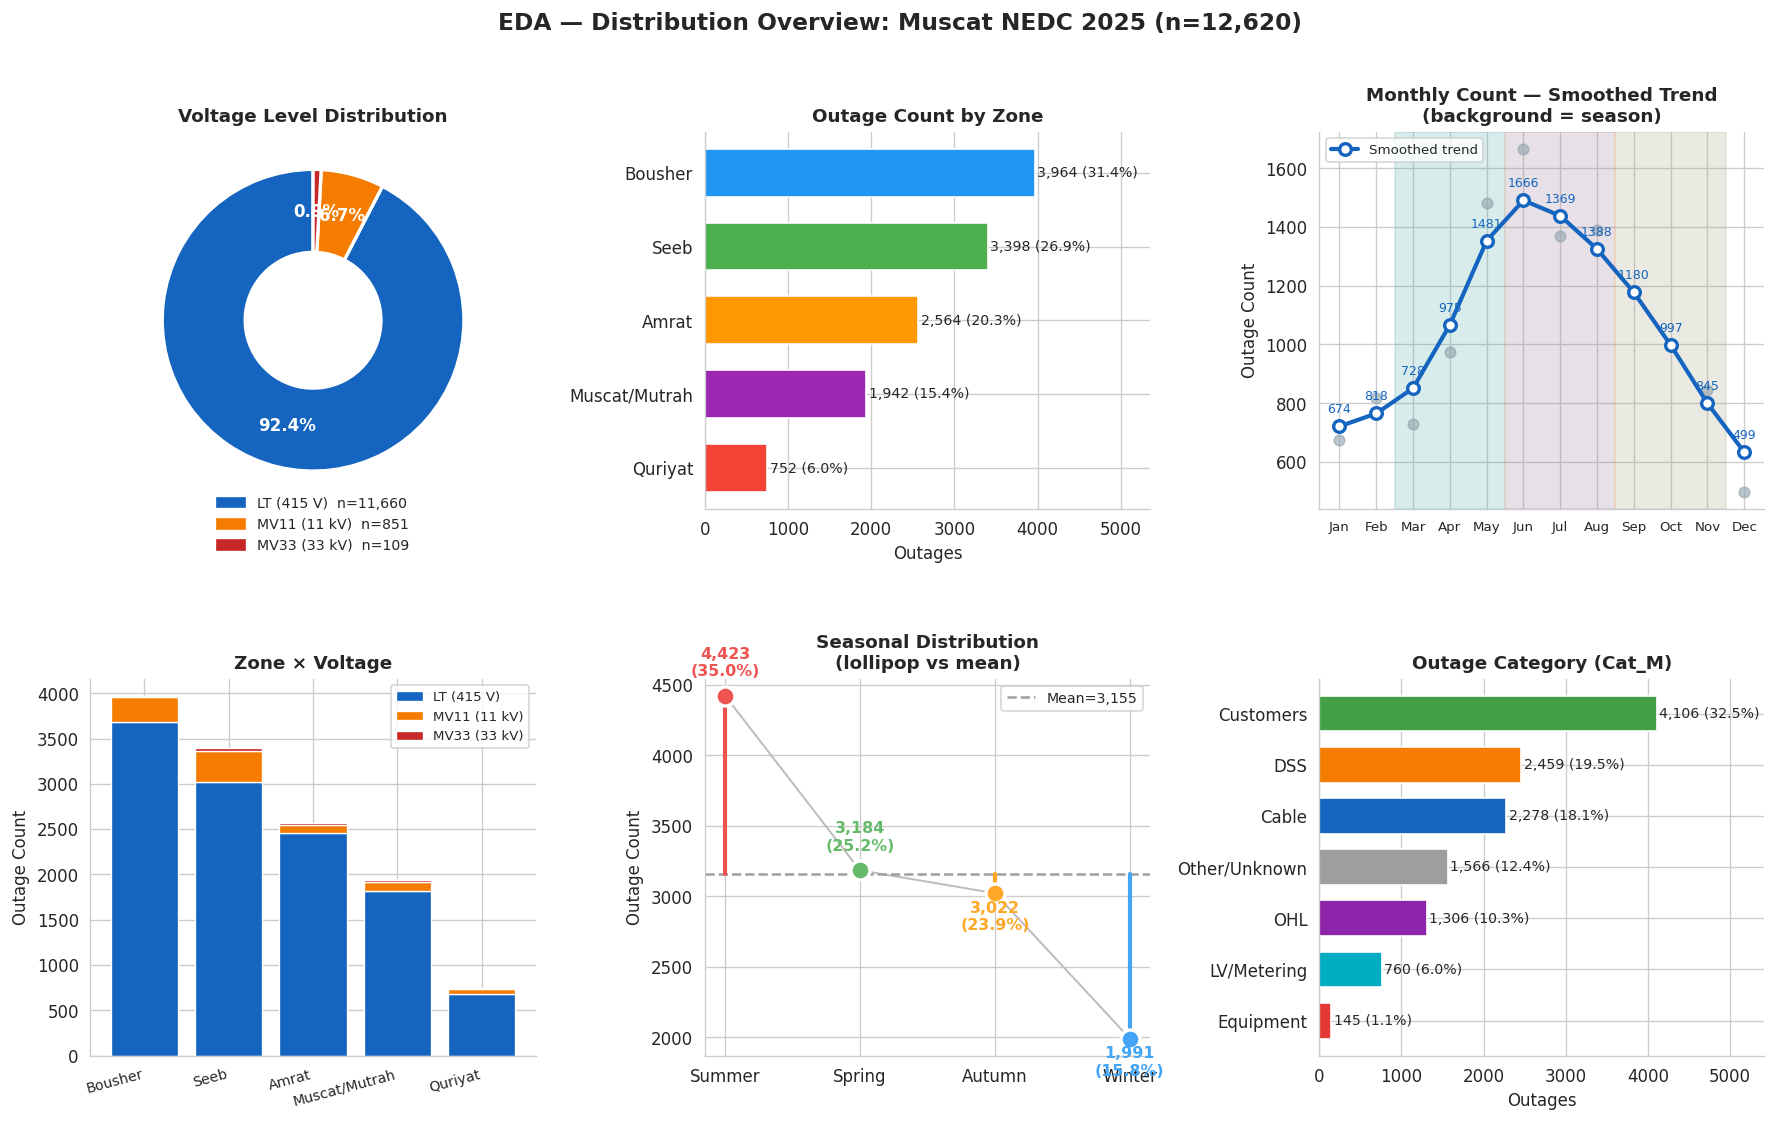

Summer/Winter ratio: 2.22×


In [29]:
# ── Distribution by voltage, zone, season, category ─────────────────────────
vc = df['Voltage'].value_counts().reindex(['LT','11','33'])
zc = df['Zone'].value_counts().reindex(ZONES)
seasonal = df.groupby('Season').size().reindex(['Winter','Spring','Summer','Autumn'])
monthly  = df.groupby('Month').size().reindex(range(1,13), fill_value=0)

fig = plt.figure(figsize=(18,10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)
fig.suptitle('EDA \u2014 Distribution Overview: Muscat NEDC 2025 (n=12,620)',
             fontsize=14, fontweight='bold')

# Voltage donut
ax0 = fig.add_subplot(gs[0,0])
wedges,texts,ats = ax0.pie(vc.values, labels=None, autopct='%1.1f%%', startangle=90,
    colors=[VCOLS[v] for v in vc.index], pctdistance=0.72,
    wedgeprops=dict(width=0.55, edgecolor='white', lw=2))
for at in ats: at.set_fontsize(10); at.set_color('white'); at.set_fontweight('bold')
ax0.legend(handles=[mpatches.Patch(color=VCOLS[v],label=f'{VLABS[v]}  n={vc[v]:,}') for v in vc.index],
           loc='lower center', bbox_to_anchor=(0.5,-0.15), fontsize=8.5, frameon=False)
ax0.set_title('Voltage Level Distribution', fontsize=11, fontweight='bold')

# Zone bar
ax1 = fig.add_subplot(gs[0,1])
bars = ax1.barh(zc.index[::-1], zc.values[::-1], color=ZCOLS[::-1], edgecolor='white', height=0.65)
for bar,val in zip(bars, zc.values[::-1]):
    ax1.text(bar.get_width()+30, bar.get_y()+bar.get_height()/2,
             f'{val:,} ({val/len(df)*100:.1f}%)', va='center', fontsize=8.5)
ax1.set_title('Outage Count by Zone', fontsize=11, fontweight='bold')
ax1.set_xlabel('Outages'); ax1.set_xlim(0, zc.max()*1.35)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Monthly line with season shading
ax2 = fig.add_subplot(gs[0,2])
smooth = gaussian_filter1d(monthly.values.astype(float), sigma=1.0)
season_spans = [(12,2,'Winter'),(3,5,'Spring'),(6,8,'Summer'),(9,11,'Autumn')]
for s,e,sn in season_spans:
    ax2.axvspan(s-0.5, e+0.5, color=SCOLS[sn], alpha=0.12)
ax2.scatter(range(1,13), monthly.values, color='#90A4AE', s=40, alpha=0.6)
ax2.plot(range(1,13), smooth, 'o-', color='#1565C0', lw=2.5,
         markerfacecolor='white', markeredgewidth=2, markersize=7, label='Smoothed trend')
for xi, (raw, sm) in enumerate(zip(monthly.values, smooth), 1):
    ax2.annotate(f'{int(raw)}', (xi, sm), xytext=(0,8),
                 textcoords='offset points', ha='center', fontsize=7.5, color='#1565C0')
ax2.set_xticks(range(1,13)); ax2.set_xticklabels(MONTHS, fontsize=8)
ax2.set_ylabel('Outage Count')
ax2.set_title('Monthly Count \u2014 Smoothed Trend\n(background = season)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8); ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# Voltage × zone stacked bar
ax3 = fig.add_subplot(gs[1,0])
vz = df.groupby(['Zone','Voltage']).size().unstack(fill_value=0).reindex(ZONES)
bottom = np.zeros(len(ZONES))
for v in ['LT','11','33']:
    if v in vz.columns:
        ax3.bar(range(len(ZONES)), vz[v].values, bottom=bottom,
                color=VCOLS[v], label=VLABS[v], edgecolor='white', lw=0.8)
        bottom += vz[v].values
ax3.set_xticks(range(len(ZONES))); ax3.set_xticklabels(ZONES, rotation=15, ha='right', fontsize=8.5)
ax3.set_ylabel('Outage Count'); ax3.legend(fontsize=8)
ax3.set_title('Zone \u00d7 Voltage', fontsize=11, fontweight='bold')
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

# Seasonal lollipop
ax4 = fig.add_subplot(gs[1,1])
seas_ord = ['Summer','Spring','Autumn','Winter']
seas_v   = [seasonal[s] for s in seas_ord]
seas_c   = [SCOLS[s] for s in seas_ord]
mean_s   = np.mean(seas_v)
ax4.axhline(mean_s, color='#9E9E9E', ls='--', lw=1.5, label=f'Mean={mean_s:,.0f}')
for i,(s,v,c) in enumerate(zip(seas_ord,seas_v,seas_c)):
    ax4.plot([i,i],[mean_s,v], color=c, lw=2.5)
    ax4.scatter([i],[v], color=c, s=130, zorder=3, edgecolors='white', lw=2)
    ax4.annotate(f'{v:,}\n({v/len(df)*100:.1f}%)', (i,v),
                 xytext=(0, 12 if v>=mean_s else -22),
                 textcoords='offset points', ha='center', fontsize=9.5, fontweight='bold', color=c)
ax4.plot(range(4), seas_v, color='#BDBDBD', lw=1.2, ls='-', zorder=1)
ax4.set_xticks(range(4)); ax4.set_xticklabels(seas_ord, fontsize=10)
ax4.set_ylabel('Outage Count')
ax4.set_title('Seasonal Distribution\n(lollipop vs mean)', fontsize=11, fontweight='bold')
ax4.legend(fontsize=8.5); ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)

# Category bar
ax5 = fig.add_subplot(gs[1,2])
cat_cnt = df['Cat_M'].value_counts().sort_values(ascending=True)
ax5.barh(cat_cnt.index, cat_cnt.values,
         color=[CAT_COLS.get(c,'#9E9E9E') for c in cat_cnt.index],
         edgecolor='white', height=0.7)
for i,(c,v) in enumerate(zip(cat_cnt.index, cat_cnt.values)):
    ax5.text(v+30, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=8.5)
ax5.set_title('Outage Category (Cat_M)', fontsize=11, fontweight='bold')
ax5.set_xlabel('Outages'); ax5.set_xlim(0, cat_cnt.max()*1.32)
ax5.spines['top'].set_visible(False); ax5.spines['right'].set_visible(False)

plt.savefig('eda1_distribution_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Summer/Winter ratio: {seasonal["Summer"]/seasonal["Winter"]:.2f}\u00d7')

## 2.2  Pareto Analysis

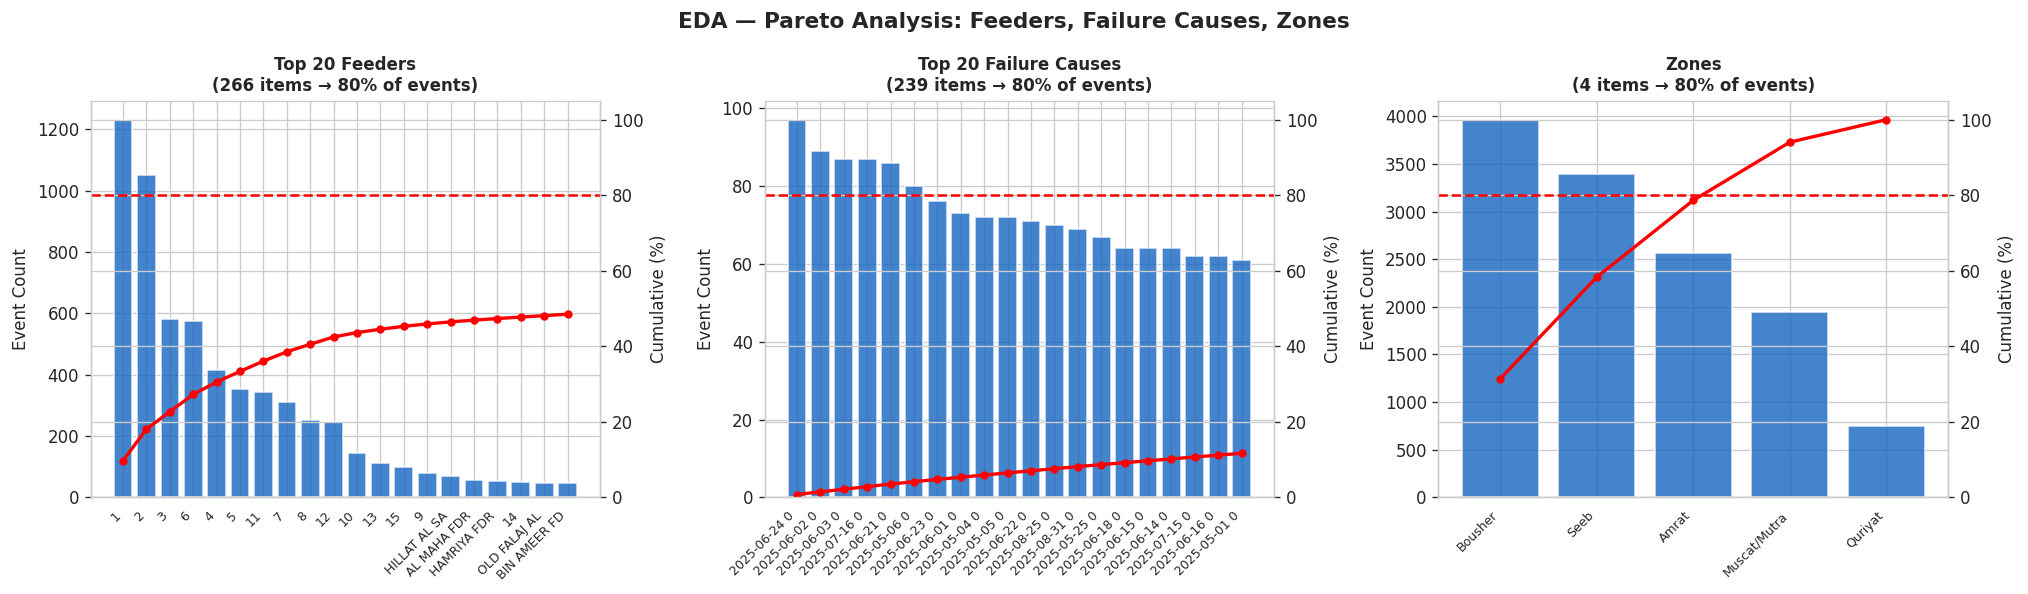

Total feeders: 1,401
Feeders accounting for 80% of events: 266 (19.0%)


In [30]:
# ── Pareto: feeders, causes, zones ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('EDA \u2014 Pareto Analysis: Feeders, Failure Causes, Zones',
             fontsize=13, fontweight='bold')

for ax, col, title, n_show in zip(
        axes,
        ['Feeder','Outage Failure Cause','Zone'],
        ['Top 20 Feeders','Top 20 Failure Causes','Zones'],
        [20, 20, 5]):
    col_name = 'Feeder' if col=='Feeder' else 'Outage Failure Cause' if 'Cause' in col else 'Zone'
    if col_name not in df.columns:
        col_name = [c for c in df.columns if col.split()[0].lower() in c.lower()][0]
    counts = df[col_name].value_counts()
    top = counts.head(n_show)
    cumsum = counts.cumsum() / counts.sum() * 100
    ax2 = ax.twinx()
    ax.bar(range(len(top)), top.values, color='#1565C0', alpha=0.8, edgecolor='white')
    ax2.plot(range(len(cumsum.head(n_show))), cumsum.head(n_show).values,
             'r-o', markersize=4, lw=2, label='Cumulative %')
    ax2.axhline(80, color='red', ls='--', lw=1.5, label='80% threshold')
    n_to_80 = (cumsum <= 80).sum() + 1
    ax.set_xticks(range(len(top)))
    ax.set_xticklabels([str(i)[:12] for i in top.index], rotation=45, ha='right', fontsize=7.5)
    ax.set_ylabel('Event Count'); ax2.set_ylabel('Cumulative (%)')
    ax2.set_ylim(0,105)
    ax.set_title(f'{title}\n({n_to_80} items \u2192 80% of events)', fontsize=10, fontweight='bold')
    ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('eda2_pareto.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
feeder_col = [c for c in df.columns if 'feeder' in c.lower()][0]
n_feeders  = df[feeder_col].nunique()
feed_cnt   = df[feeder_col].value_counts()
feed_cum   = feed_cnt.cumsum()
n_to_80f   = (feed_cum/len(df) <= 0.80).sum() + 1
print(f'Total feeders: {n_feeders:,}')
print(f'Feeders accounting for 80% of events: {n_to_80f} ({n_to_80f/n_feeders*100:.1f}%)')

## 2.3  Duration Analysis with 95% CI

---



---



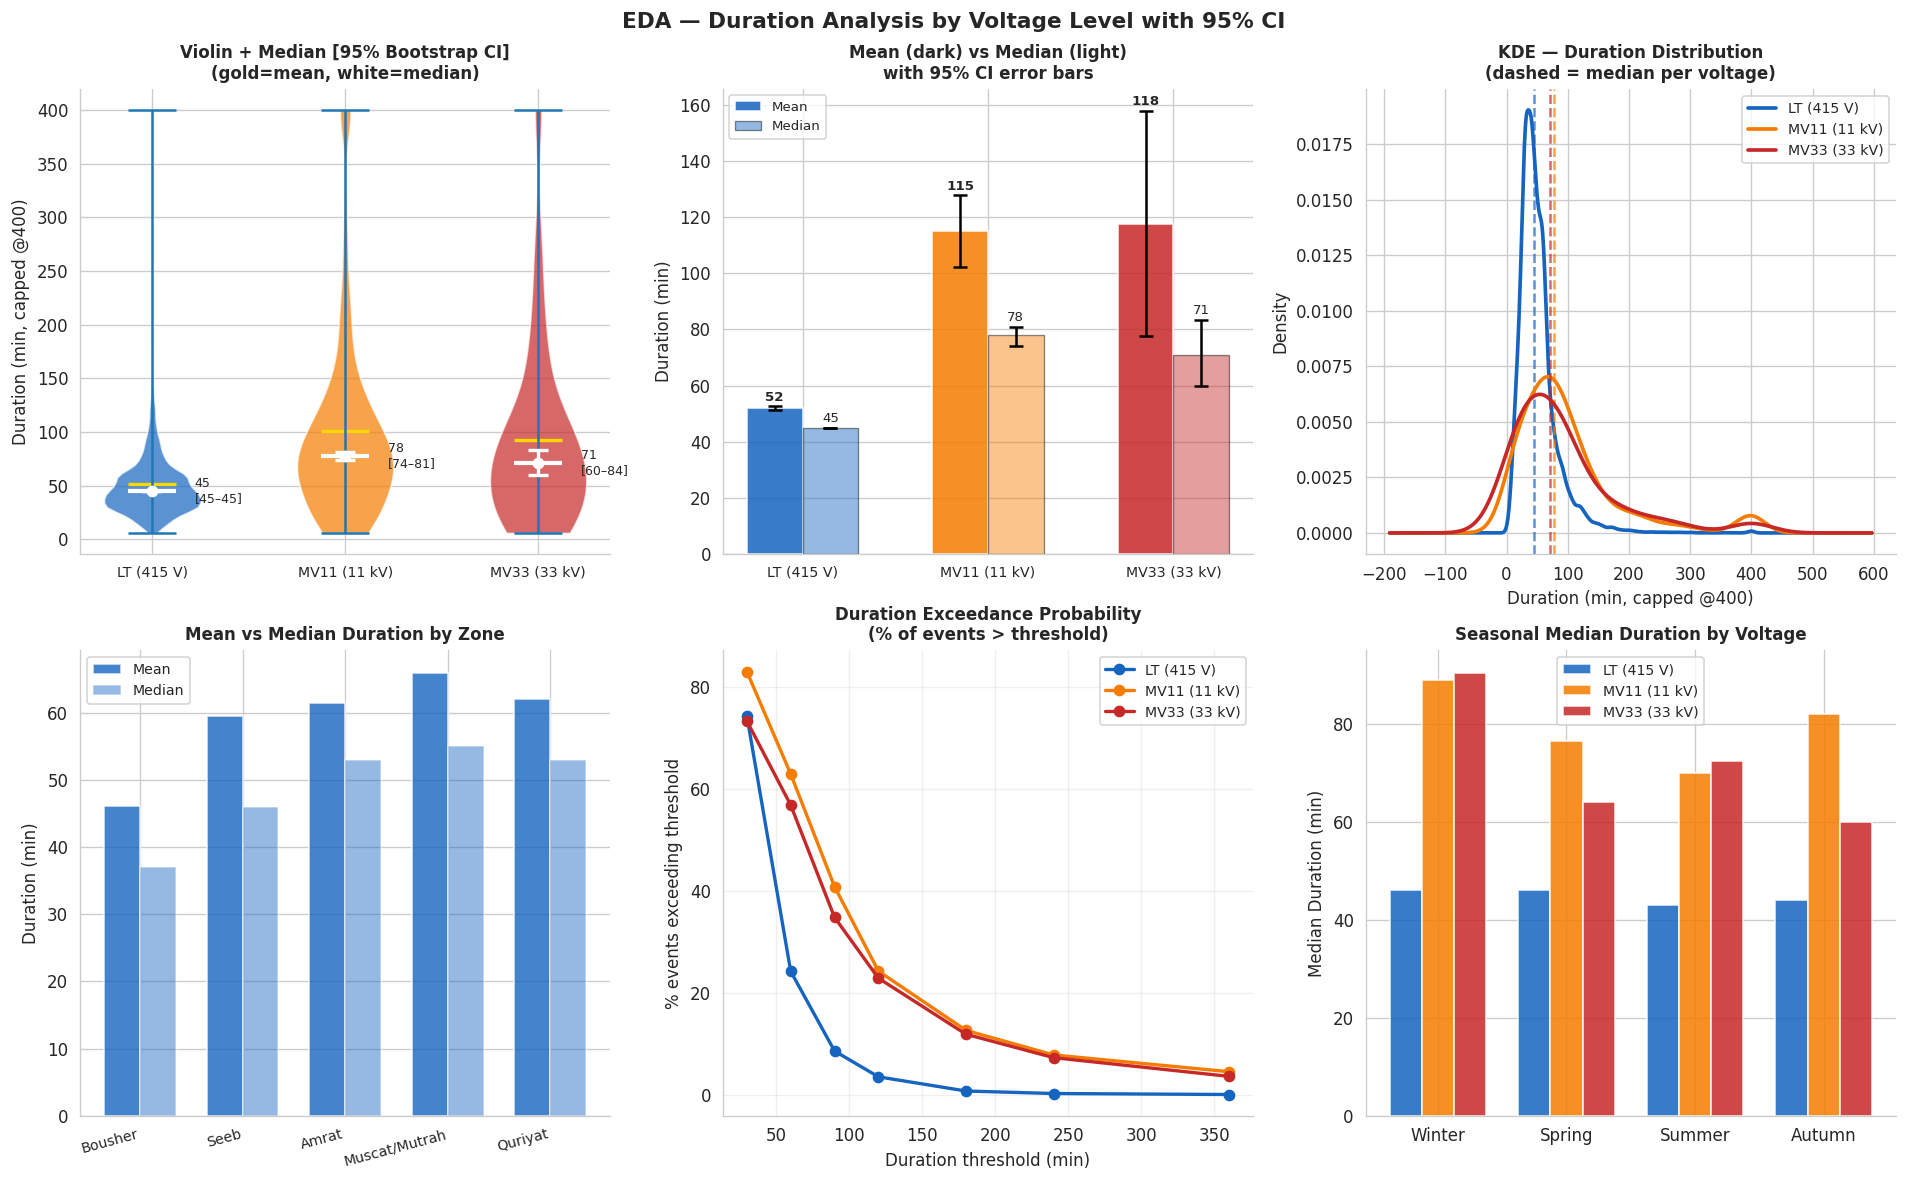

Duration summary with 95% CI:
Voltage                    n    Median [Bootstrap CI]            Mean [t-CI]
LT (415 V)            11,660     45 [   45–45   ]      52 [    51–53    ]
MV11 (11 kV)             851     78 [   74–81   ]     115 [   102–128   ]
MV33 (33 kV)             109     71 [   60–84   ]     118 [    78–158   ]


In [31]:
# ── Duration with violin + CI bars + mean vs median ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA \u2014 Duration Analysis by Voltage Level with 95% CI',
             fontsize=13, fontweight='bold')

dur_stats = {}
for v in ['LT','11','33']:
    x = df[df['Voltage']==v]['Duration_min'].values
    med = float(np.median(x)); mlo,mhi = boot_median_ci(x)
    mn  = float(np.mean(x));   tlo,thi = t_mean_ci(x)
    dur_stats[v] = dict(n=len(x), med=med, mlo=mlo, mhi=mhi, mean=mn, tlo=tlo, thi=thi)

# Violin
ax = axes[0,0]
parts = ax.violinplot([df[df['Voltage']==v]['Duration_min'].clip(upper=400) for v in ['LT','11','33']],
                      positions=[1,2,3], showmedians=True, showmeans=True)
for pc,v in zip(parts['bodies'],['LT','11','33']):
    pc.set_facecolor(VCOLS[v]); pc.set_alpha(0.7)
parts['cmedians'].set_color('white'); parts['cmedians'].set_lw(2.5)
parts['cmeans'].set_color('gold');    parts['cmeans'].set_lw(2)
for i,v in enumerate(['LT','11','33'],1):
    d = dur_stats[v]
    ax.errorbar(i, d['med'], yerr=[[d['med']-d['mlo']],[d['mhi']-d['med']]],
                fmt='o', color='white', capsize=6, capthick=2, elinewidth=2, zorder=6, markersize=6)
    ax.text(i+0.22, d['med'], f"{d['med']:.0f}\n[{d['mlo']:.0f}\u2013{d['mhi']:.0f}]",
            fontsize=7.5, va='center')
ax.set_xticks([1,2,3]); ax.set_xticklabels([VLABS[v] for v in ['LT','11','33']], fontsize=8.5)
ax.set_ylabel('Duration (min, capped @400)')
ax.set_title('Violin + Median [95% Bootstrap CI]\n(gold=mean, white=median)', fontsize=10, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Mean vs Median with CI
ax2 = axes[0,1]; x3 = np.arange(3); w = 0.3
for xi,v in enumerate(['LT','11','33']):
    d = dur_stats[v]
    ax2.bar(xi-w/2, d['mean'], w, color=VCOLS[v], alpha=0.85, edgecolor='white', label='Mean' if xi==0 else '')
    ax2.bar(xi+w/2, d['med'],  w, color=VCOLS[v], alpha=0.45, edgecolor='black', lw=0.8, label='Median' if xi==0 else '')
    ax2.errorbar(xi-w/2, d['mean'], yerr=[[d['mean']-d['tlo']],[d['thi']-d['mean']]],
                 fmt='none', color='black', capsize=4, capthick=1.5, elinewidth=1.5)
    ax2.errorbar(xi+w/2, d['med'], yerr=[[d['med']-d['mlo']],[d['mhi']-d['med']]],
                 fmt='none', color='black', capsize=4, capthick=1.5, elinewidth=1.5)
    ax2.text(xi-w/2, d['thi']+2, f"{d['mean']:.0f}", ha='center', fontsize=8, fontweight='bold')
    ax2.text(xi+w/2, d['mhi']+2, f"{d['med']:.0f}", ha='center', fontsize=8)
ax2.set_xticks(x3); ax2.set_xticklabels([VLABS[v] for v in ['LT','11','33']], fontsize=8.5)
ax2.set_ylabel('Duration (min)')
ax2.set_title('Mean (dark) vs Median (light)\nwith 95% CI error bars', fontsize=10, fontweight='bold')
ax2.legend(fontsize=8); ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# KDE
ax3 = axes[0,2]
for v in ['LT','11','33']:
    df[df['Voltage']==v]['Duration_min'].clip(upper=400).plot.kde(
        ax=ax3, color=VCOLS[v], lw=2.2, label=VLABS[v])
    ax3.axvline(dur_stats[v]['med'], color=VCOLS[v], lw=1.5, ls='--', alpha=0.7)
ax3.set_xlabel('Duration (min, capped @400)'); ax3.set_ylabel('Density')
ax3.set_title('KDE \u2014 Duration Distribution\n(dashed = median per voltage)', fontsize=10, fontweight='bold')
ax3.legend(fontsize=8.5); ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

# Zone mean duration
ax4 = axes[1,0]
zone_dur = df.groupby('Zone')['Duration_min'].agg(['mean','median']).reindex(ZONES)
x4 = np.arange(len(ZONES)); w4 = 0.35
ax4.bar(x4-w4/2, zone_dur['mean'],   w4, color='#1565C0', alpha=0.8, label='Mean')
ax4.bar(x4+w4/2, zone_dur['median'], w4, color='#1565C0', alpha=0.45, label='Median')
ax4.set_xticks(x4); ax4.set_xticklabels(ZONES, rotation=15, ha='right', fontsize=8.5)
ax4.set_ylabel('Duration (min)')
ax4.set_title('Mean vs Median Duration by Zone', fontsize=10, fontweight='bold')
ax4.legend(fontsize=8.5); ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)

# Exceedance thresholds
ax5 = axes[1,1]
thresholds = [30,60,90,120,180,240,360]
for v in ['LT','11','33']:
    sub = df[df['Voltage']==v]['Duration_min']
    pcts = [(sub>t).mean()*100 for t in thresholds]
    ax5.plot(thresholds, pcts, 'o-', color=VCOLS[v], lw=2, label=VLABS[v], markersize=6)
ax5.set_xlabel('Duration threshold (min)'); ax5.set_ylabel('% events exceeding threshold')
ax5.set_title('Duration Exceedance Probability\n(% of events > threshold)', fontsize=10, fontweight='bold')
ax5.legend(fontsize=8.5); ax5.grid(True, alpha=0.3)
ax5.spines['top'].set_visible(False); ax5.spines['right'].set_visible(False)

# Seasonal median duration
ax6 = axes[1,2]
seas_dur = df.groupby(['Season','Voltage'])['Duration_min'].median().unstack()
seas_dur_ord = seas_dur.reindex(['Winter','Spring','Summer','Autumn'])
x6 = np.arange(4); w6 = 0.25
for i,v in enumerate(['LT','11','33']):
    if v in seas_dur_ord.columns:
        vals = [seas_dur_ord.loc[s,v] if s in seas_dur_ord.index else 0 for s in ['Winter','Spring','Summer','Autumn']]
        ax6.bar(x6+(i-1)*w6, vals, w6, color=VCOLS[v], label=VLABS[v], edgecolor='white', alpha=0.85)
ax6.set_xticks(x6); ax6.set_xticklabels(['Winter','Spring','Summer','Autumn'])
ax6.set_ylabel('Median Duration (min)')
ax6.set_title('Seasonal Median Duration by Voltage', fontsize=10, fontweight='bold')
ax6.legend(fontsize=8.5); ax6.spines['top'].set_visible(False); ax6.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('eda3_duration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Duration summary with 95% CI:')
print(f'{"Voltage":<20} {"n":>7} {"Median [Bootstrap CI]":>24} {"Mean [t-CI]":>22}')
for v in ['LT','11','33']:
    d = dur_stats[v]
    print(f'{VLABS[v]:<20} {d["n"]:>7,}  {d["med"]:>5.0f} [{d["mlo"]:>5.0f}\u2013{d["mhi"]:<5.0f}]  {d["mean"]:>6.0f} [{d["tlo"]:>6.0f}\u2013{d["thi"]:<6.0f}]')

---
# PART 3 — RQ1: Temporal Patterns & Seasonal Fault Mode Shift

**H1:** Outage events exhibit non-random temporal patterns, including clustering behaviour, within each voltage level.

**Extended sub-question:** Does the fault category distribution shift significantly between seasons across voltage levels?

**Uncertainty:** Bootstrap CI (n=500) on IET skewness; Bootstrap CI (n=200) on Cramér's V.

---

## 3.1  Daily Time Series with Rolling Averages

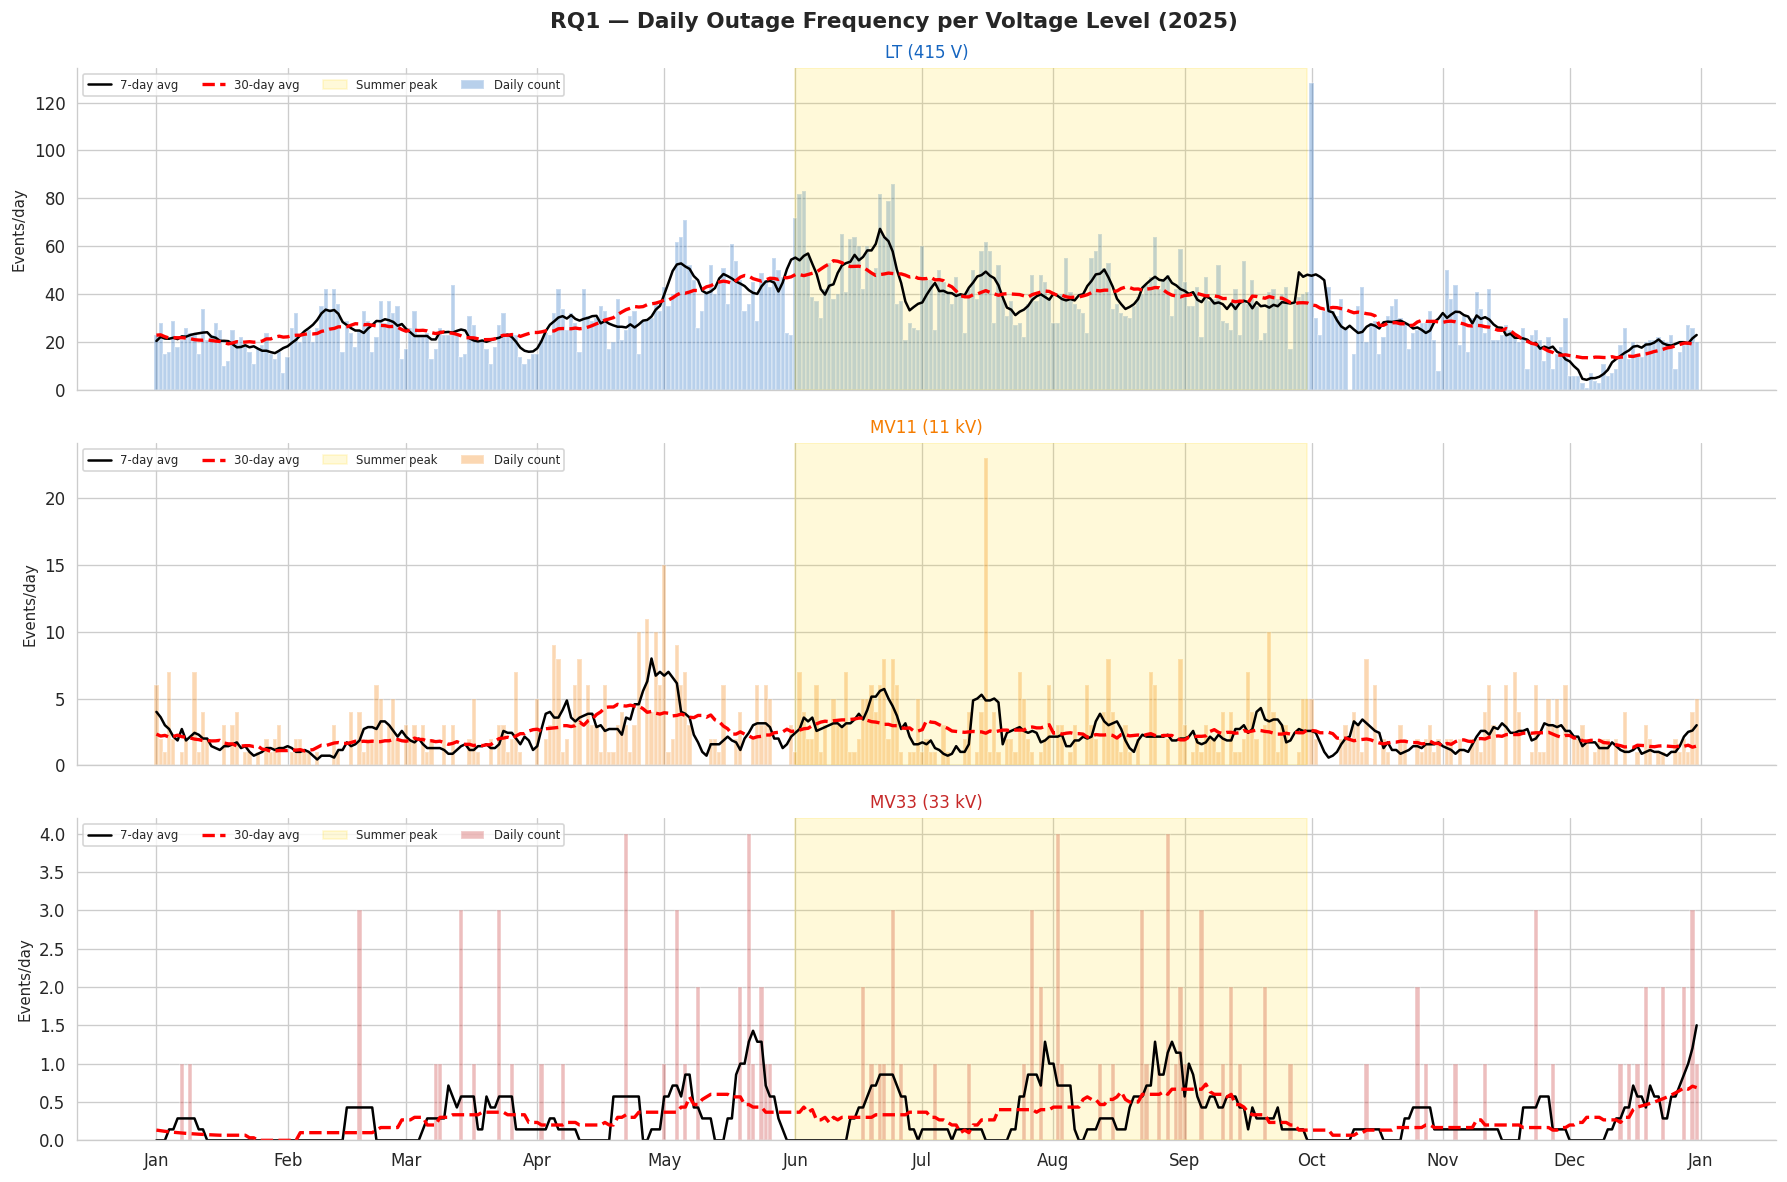

In [32]:
import matplotlib.dates as mdates

all_days = pd.date_range('2025-01-01','2025-12-31').date
fig, axes = plt.subplots(3, 1, figsize=(15,10), sharex=True)
fig.suptitle('RQ1 \u2014 Daily Outage Frequency per Voltage Level (2025)',
             fontsize=13, fontweight='bold')

for ax, volt in zip(axes, ['LT','11','33']):
    sub   = df[df['Voltage']==volt]
    daily = sub.groupby('Date').size().reindex(all_days, fill_value=0)
    daily.index = pd.to_datetime(daily.index)
    roll7  = daily.rolling(7,  center=True, min_periods=1).mean()
    roll30 = daily.rolling(30, center=True, min_periods=1).mean()
    ax.bar(daily.index, daily.values, color=VCOLS[volt], alpha=0.3, width=1, label='Daily count')
    ax.plot(daily.index, roll7.values,  color='black', lw=1.5, label='7-day avg')
    ax.plot(daily.index, roll30.values, color='red',   lw=2.0, ls='--', label='30-day avg')
    ax.axvspan(pd.Timestamp('2025-06-01'), pd.Timestamp('2025-09-30'),
               color='gold', alpha=0.15, label='Summer peak')
    ax.set_ylabel('Events/day', fontsize=9)
    ax.set_title(VLABS[volt], fontsize=10, color=VCOLS[volt])
    ax.legend(fontsize=7, loc='upper left', ncol=4)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_daily_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.2  IET Skewness Analysis with 95% Bootstrap CI

In [33]:
print('H1 Test: IET Skewness with 95% Bootstrap CI (n=500)')
print('Threshold: Poisson process \u2248 2.0; clustering threshold = 1.5')
print(f'{"Voltage":<20} {"n (IET)":>8} {"Mean":>8} {"Median":>8} {"Skew [95% CI]":>20} {"CI>1.5?":>10} {"H1":>12}')
print('-'*92)

iet_stats = {}
for v in ['LT','11','33']:
    x = iet_data[v].values
    skew = float(pd.Series(x).skew())
    np.random.seed(42)
    bs = [float(pd.Series(np.random.choice(x, min(len(x),2000), replace=True)).skew())
          for _ in range(500)]
    lo, hi = float(np.percentile(bs,2.5)), float(np.percentile(bs,97.5))
    iet_stats[v] = dict(skew=skew, lo=lo, hi=hi,
                        mean=float(np.mean(x)), median=float(np.median(x)), n=len(x))
    above = '\u2713 Yes' if lo>1.5 else ('~' if skew>1.5 else '\u2717 No')
    verdict = '\u2713 SUPPORTED' if skew>1.5 else '\u2717 NOT SUPPORTED'
    print(f'{VLABS[v]:<20} {len(x):>8,} {np.mean(x):>8.2f}h {np.median(x):>8.2f}h'
          f' {skew:>6.2f} [{lo:>5.2f}\u2013{hi:<5.2f}] {above:>10} {verdict:>12}')

plt.tight_layout()
plt.savefig('fig2_iet_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

H1 Test: IET Skewness with 95% Bootstrap CI (n=500)
Threshold: Poisson process ≈ 2.0; clustering threshold = 1.5
Voltage               n (IET)     Mean   Median        Skew [95% CI]    CI>1.5?           H1
--------------------------------------------------------------------------------------------
LT (415 V)             11,041     0.69h     0.38h   3.24 [ 2.95–3.52 ]      ✓ Yes  ✓ SUPPORTED
MV11 (11 kV)              573    13.63h     7.55h   1.86 [ 1.64–2.05 ]      ✓ Yes  ✓ SUPPORTED
MV33 (33 kV)               71    99.77h    56.75h   1.69 [ 1.11–2.26 ]          ~  ✓ SUPPORTED


<Figure size 768x576 with 0 Axes>

H1 Test: IET Skewness with 95% Bootstrap CI (n=500)
Threshold: Poisson process ≈ 2.0; clustering threshold = 1.5
Voltage               n (IET)     Mean   Median        Skew [95% CI]    CI>1.5?           H1
--------------------------------------------------------------------------------------------
LT (415 V)             11,041     0.69h     0.38h   3.24 [ 2.95–3.52 ]      ✓ Yes  ✓ SUPPORTED
MV11 (11 kV)              573    13.63h     7.55h   1.86 [ 1.64–2.05 ]      ✓ Yes  ✓ SUPPORTED
MV33 (33 kV)               71    99.77h    56.75h   1.69 [ 1.11–2.26 ]          ~  ✓ SUPPORTED


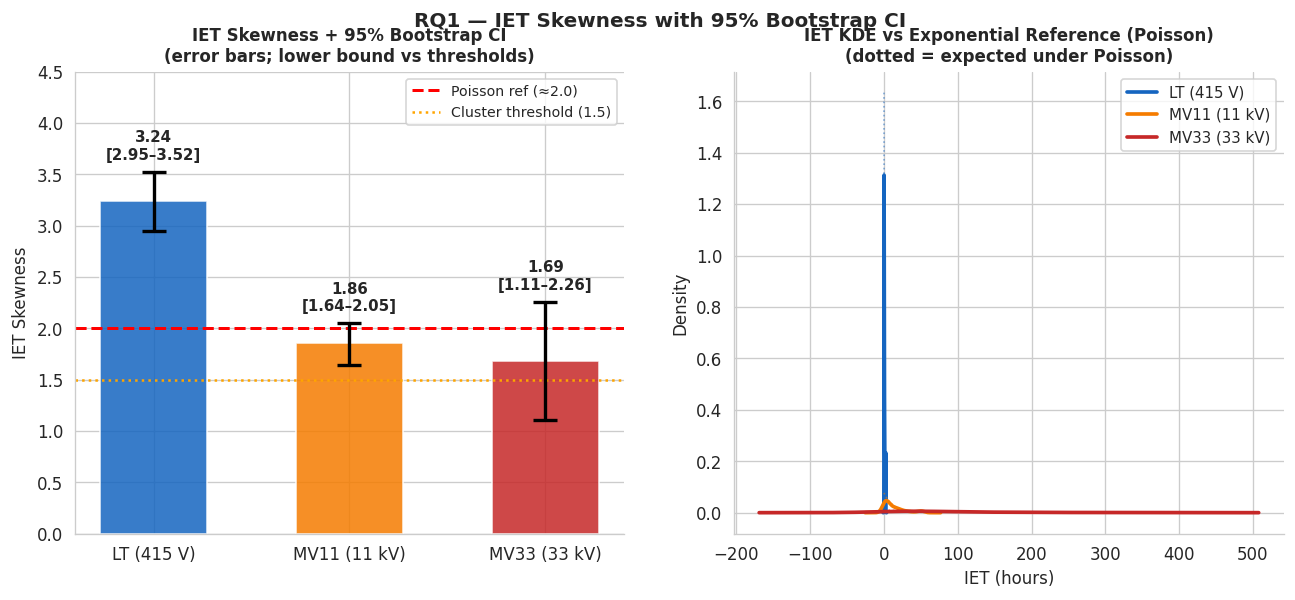

In [34]:
print('H1 Test: IET Skewness with 95% Bootstrap CI (n=500)')
print('Threshold: Poisson process \u2248 2.0; clustering threshold = 1.5')
print(f'{"Voltage":<20} {"n (IET)":>8} {"Mean":>8} {"Median":>8} {"Skew [95% CI]":>20} {"CI>1.5?":>10} {"H1":>12}')
print('-'*92)

iet_stats = {}
for v in ['LT','11','33']:
    x = iet_data[v].values
    skew = float(pd.Series(x).skew())
    np.random.seed(42)
    bs = [float(pd.Series(np.random.choice(x, min(len(x),2000), replace=True)).skew())
          for _ in range(500)]
    lo, hi = float(np.percentile(bs,2.5)), float(np.percentile(bs,97.5))
    iet_stats[v] = dict(skew=skew, lo=lo, hi=hi,
                        mean=float(np.mean(x)), median=float(np.median(x)), n=len(x))
    above = '\u2713 Yes' if lo>1.5 else ('~' if skew>1.5 else '\u2717 No')
    verdict = '\u2713 SUPPORTED' if skew>1.5 else '\u2717 NOT SUPPORTED'
    print(f'{VLABS[v]:<20} {len(x):>8,} {np.mean(x):>8.2f}h {np.median(x):>8.2f}h'
          f' {skew:>6.2f} [{lo:>5.2f}\u2013{hi:<5.2f}] {above:>10} {verdict:>12}')

# Plot: IET skewness bar + CI + IET KDE vs Poisson reference
# Plot: IET skewness bar + CI + IET KDE vs Poisson reference
fig, axes = plt.subplots(1, 2, figsize=(13,5))
fig.suptitle('RQ1 \u2014 IET Skewness with 95% Bootstrap CI', fontsize=12, fontweight='bold')

ax = axes[0]
skews = [iet_stats[v]['skew'] for v in ['LT','11','33']]
elo   = [iet_stats[v]['skew'] - iet_stats[v]['lo'] for v in ['LT','11','33']]
ehi   = [iet_stats[v]['hi']   - iet_stats[v]['skew'] for v in ['LT','11','33']]
bars  = ax.bar([VLABS[v] for v in ['LT','11','33']], skews,
               color=[VCOLS[v] for v in ['LT','11','33']], edgecolor='white', width=0.55, alpha=0.85)
ax.errorbar([0,1,2], skews, yerr=[elo, ehi],
            fmt='none', color='black', capsize=7, capthick=2, elinewidth=2, zorder=5)
ax.axhline(2.0, color='red',    ls='--', lw=1.8, label='Poisson ref (\u22482.0)')
ax.axhline(1.5, color='orange', ls=':',  lw=1.5, label='Cluster threshold (1.5)')
for bar, v in zip(bars, ['LT','11','33']):
    d = iet_stats[v]
    ax.text(bar.get_x()+bar.get_width()/2, d['hi']+0.12,
            f"{d['skew']:.2f}\n[{d['lo']:.2f}\u2013{d['hi']:.2f}]",
            ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('IET Skewness'); ax.set_ylim(0, 4.5)
ax.set_title('IET Skewness + 95% Bootstrap CI\n(error bars; lower bound vs thresholds)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8.5)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax2 = axes[1]
for v in ['LT','11','33']:
    x = iet_data[v]; clip = x.clip(upper=x.quantile(0.95))
    clip.plot.kde(ax=ax2, color=VCOLS[v], lw=2.2, label=VLABS[v])
    x_ref = np.linspace(0, clip.max(), 100)
    ax2.plot(x_ref, expon.pdf(x_ref, scale=clip.mean()),
             color=VCOLS[v], lw=1, ls=':', alpha=0.5)
ax2.set_xlabel('IET (hours)'); ax2.set_ylabel('Density')
ax2.set_title('IET KDE vs Exponential Reference (Poisson)\n(dotted = expected under Poisson)', fontsize=10, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)




plt.savefig('fig2_iet_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.3  Seasonal Fault Mode Shift — Chi-Square + Bootstrap CI on Cramér's V

Seasonal Fault Mode Shift — Chi-Square + 95% Bootstrap CI on Cramér’s V
Voltage               χ² (4 seas)    p-value           V [95% CI]   Effect           H1
----------------------------------------------------------------------------------------
LT (415 V)                   5866     0.0000    0.496 [0.480–0.515] Large***  ✓ SUPPORTED
MV11 (11 kV)                   36     0.0000    0.228 [0.166–0.311] Medium***  ✓ SUPPORTED
MV33 (33 kV)                   33     0.0001    0.398 [0.273–0.580]   Large*  ✓ SUPPORTED


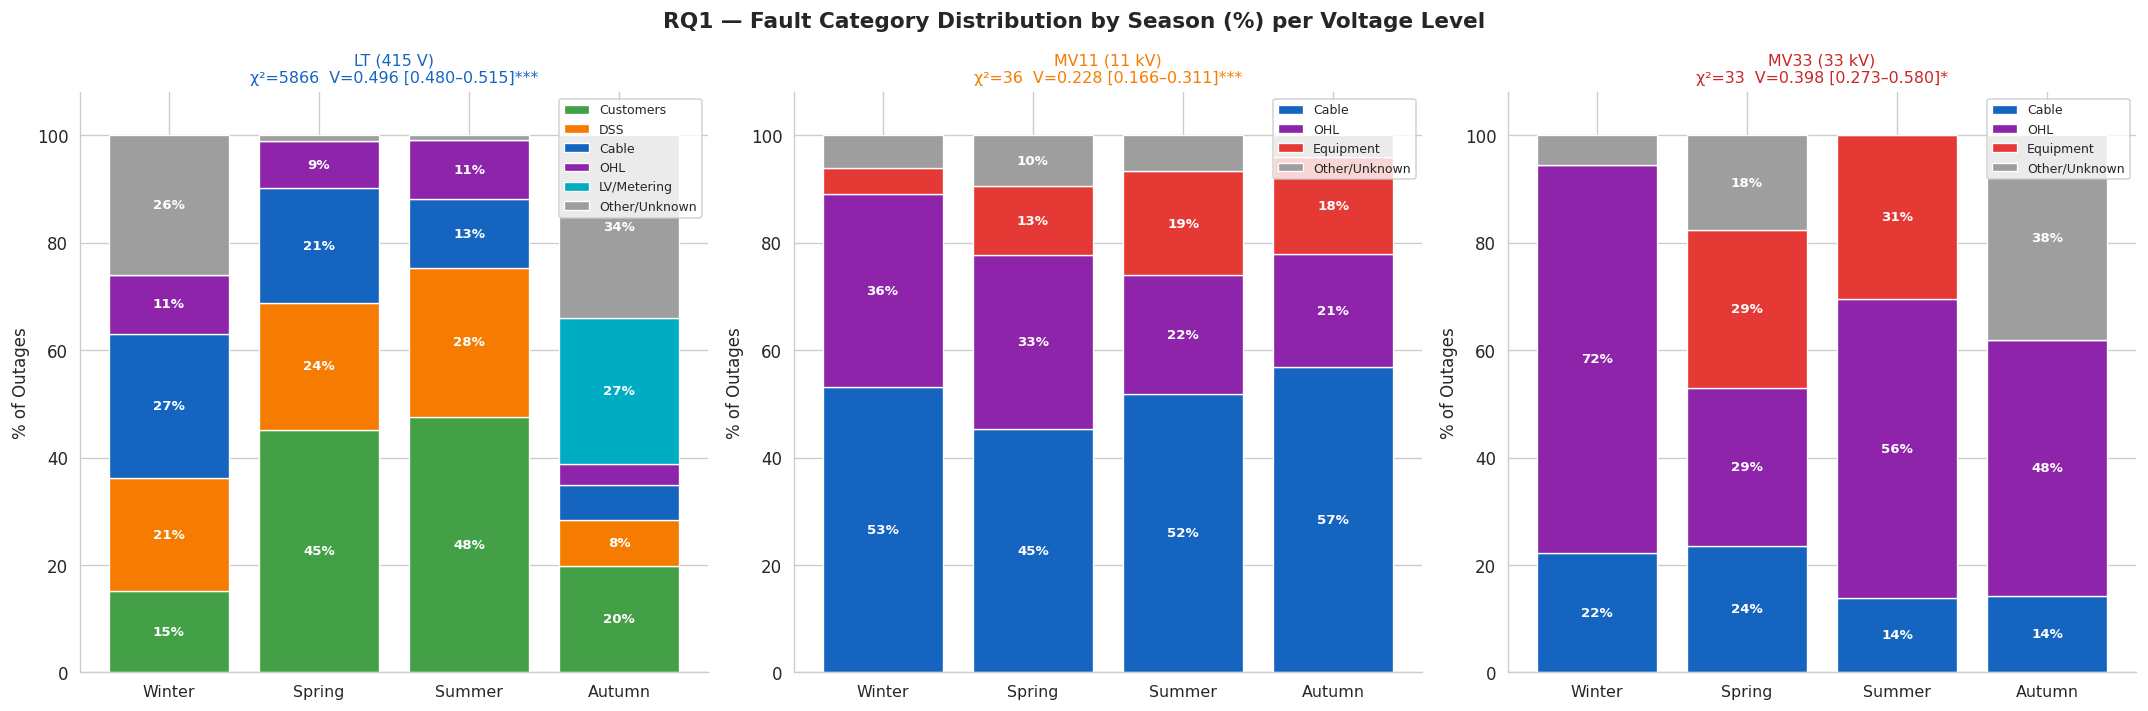

In [35]:
SEASONS_ORD = ['Winter','Spring','Summer','Autumn']
CATS_LT = ['Customers','DSS','Cable','OHL','LV/Metering','Other/Unknown']
CATS_MV = ['Cable','OHL','Equipment','Other/Unknown']

print('Seasonal Fault Mode Shift \u2014 Chi-Square + 95% Bootstrap CI on Cram\u00e9r\u2019s V')
print(f'{"Voltage":<20} {"\u03c7\u00b2 (4 seas)":>12} {"p-value":>10} {"V [95% CI]":>20} {"Effect":>8} {"H1":>12}')
print('-'*88)

season_results = {}
for v in ['LT','11','33']:
    sub_sw = df[(df['Voltage']==v) & df['Season'].isin(['Summer','Winter'])]
    V, lo_v, hi_v, p_sw = boot_V_ci(sub_sw)
    sub4 = df[df['Voltage']==v]
    ct4  = pd.crosstab(sub4['Season'], sub4['Cat_M'])
    c2_4, p4, _, _ = chi2_contingency(ct4)
    season_results[v] = dict(c2=c2_4, p4=p4, V=V, lo=lo_v, hi=hi_v, p_sw=p_sw)
    eff = 'Large' if V>0.3 else 'Medium' if V>0.1 else 'Small'
    sig = '***' if p_sw<0.001 else '**' if p_sw<0.01 else '*' if p_sw<0.05 else 'ns'
    verdict = '\u2713 SUPPORTED' if p_sw<0.05 else '\u2717 NOT SUPPORTED'
    print(f'{VLABS[v]:<20} {c2_4:>12.0f} {p4:>10.4f} {V:>8.3f} [{lo_v:.3f}\u2013{hi_v:.3f}] {eff+sig:>8} {verdict:>12}')

# ── Figure 1: 4-season stacked bars ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18,6))
fig.suptitle('RQ1 \u2014 Fault Category Distribution by Season (%) per Voltage Level',
             fontsize=13, fontweight='bold')

for ax, volt in zip(axes, ['LT','11','33']):
    cats = CATS_LT if volt=='LT' else CATS_MV
    sub  = df[df['Voltage']==volt]
    pct_data = []
    for s in SEASONS_ORD:
        ss = sub[sub['Season']==s]
        pcts = {c: ss['Cat_M'].value_counts().get(c,0)/max(len(ss),1)*100 for c in cats}
        pct_data.append(pcts)
    pct_df  = pd.DataFrame(pct_data, index=SEASONS_ORD)
    bottom  = np.zeros(4)
    for cat in cats:
        vals = pct_df[cat].values if cat in pct_df else np.zeros(4)
        bars2 = ax.bar(range(4), vals, bottom=bottom,
                       color=CAT_COLS.get(cat,'#9E9E9E'), label=cat, edgecolor='white', lw=0.8)
        for i,(bar,val) in enumerate(zip(bars2,vals)):
            if val>8:
                ax.text(bar.get_x()+bar.get_width()/2, bottom[i]+val/2,
                        f'{val:.0f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
        bottom += vals
    r = season_results[volt]
    sig = '***' if r['p_sw']<0.001 else '**' if r['p_sw']<0.01 else '*' if r['p_sw']<0.05 else 'ns'
    ax.set_xticks(range(4)); ax.set_xticklabels(SEASONS_ORD, fontsize=9.5)
    ax.set_ylabel('% of Outages'); ax.set_ylim(0, 108)
    ax.set_title(f'{VLABS[volt]}\n\u03c7\u00b2={r["c2"]:.0f}  V={r["V"]:.3f} [{r["lo"]:.3f}\u2013{r["hi"]:.3f}]{sig}',
                 fontsize=9.5, color=VCOLS[volt])
    ax.legend(fontsize=7.5, loc='upper right')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('rq1a_seasonal_shift_4seasons.png', dpi=150, bbox_inches='tight')
plt.show()

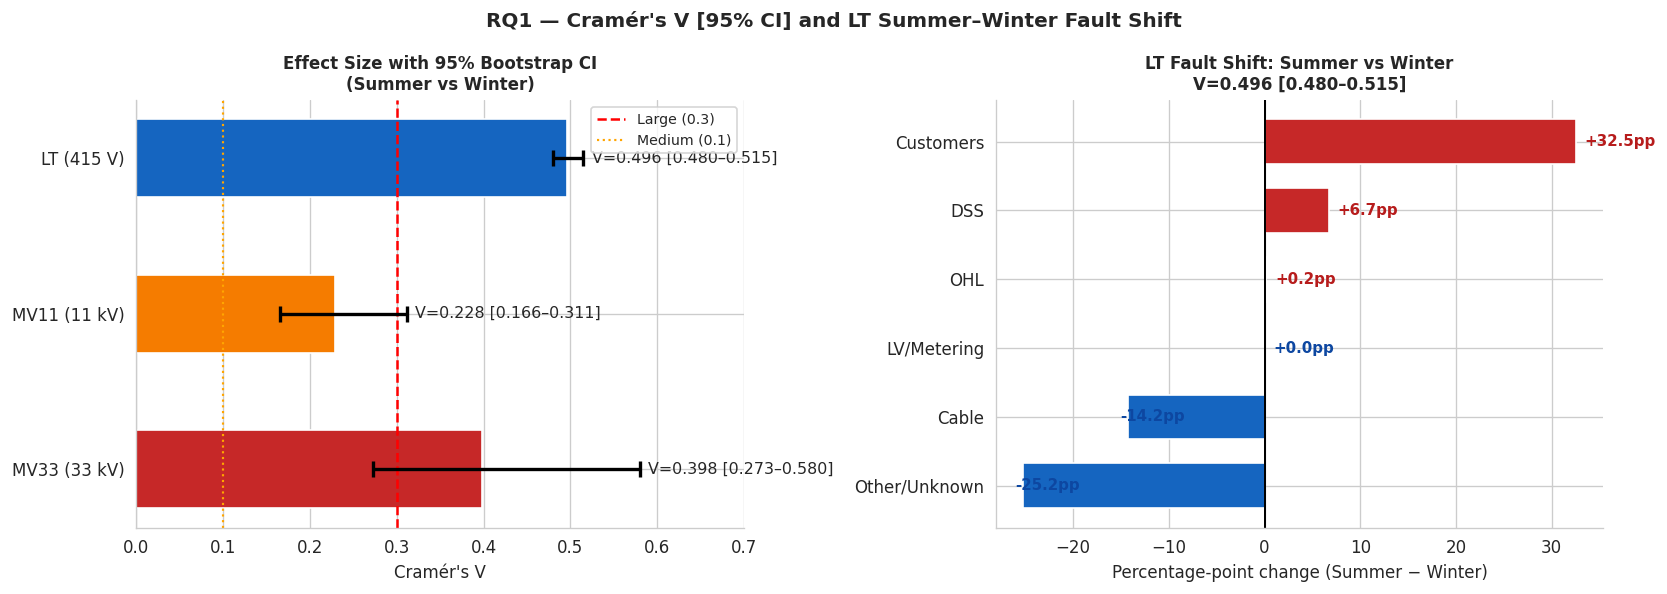

In [36]:
# ── Summer vs Winter delta diverging bar + V CI horizontal bar ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("RQ1 \u2014 Cram\u00e9r's V [95% CI] and LT Summer\u2013Winter Fault Shift",
             fontsize=12, fontweight='bold')

# V with CI
ax = axes[0]
V_vals = [season_results[v]['V']  for v in ['LT','11','33']]
elo_v  = [season_results[v]['V']  - season_results[v]['lo'] for v in ['LT','11','33']]
ehi_v  = [season_results[v]['hi'] - season_results[v]['V']  for v in ['LT','11','33']]
ax.barh([VLABS[v] for v in ['LT','11','33']][::-1], V_vals[::-1],
        color=[VCOLS[v] for v in ['LT','11','33']][::-1], edgecolor='white', height=0.5)
ax.errorbar(V_vals[::-1], [0,1,2], xerr=[elo_v[::-1],ehi_v[::-1]],
            fmt='none', color='black', capsize=5, capthick=2, elinewidth=2, zorder=5)
ax.axvline(0.3, color='red',    ls='--', lw=1.5, label='Large (0.3)')
ax.axvline(0.1, color='orange', ls=':',  lw=1.3, label='Medium (0.1)')
for i,(v,xi) in enumerate(zip(['33','11','LT'],[0,1,2])):
    d = season_results[v]
    ax.text(d['hi']+0.01, xi, f"V={d['V']:.3f} [{d['lo']:.3f}\u2013{d['hi']:.3f}]",
            va='center', fontsize=9.5)
ax.set_xlabel("Cram\u00e9r's V"); ax.set_xlim(0, 0.70)
ax.set_title("Effect Size with 95% Bootstrap CI\n(Summer vs Winter)", fontsize=10, fontweight='bold')
ax.legend(fontsize=8.5)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# LT delta
ax2 = axes[1]
sub_s = df[(df['Voltage']=='LT') & (df['Season']=='Summer')]
sub_w = df[(df['Voltage']=='LT') & (df['Season']=='Winter')]
ps = sub_s['Cat_M'].value_counts(normalize=True).mul(100).reindex(CATS_LT, fill_value=0)
pw = sub_w['Cat_M'].value_counts(normalize=True).mul(100).reindex(CATS_LT, fill_value=0)
delta = (ps - pw).sort_values()
ax2.barh(delta.index, delta.values,
         color=['#C62828' if v>0 else '#1565C0' for v in delta.values],
         edgecolor='white', height=0.65)
ax2.axvline(0, color='black', lw=1.2)
for cat, val in zip(delta.index, delta.values):
    ax2.text(val+(0.9 if val>=0 else -0.9), list(delta.index).index(cat),
             f'{val:+.1f}pp', va='center', fontsize=9, fontweight='bold',
             color='#B71C1C' if val>0 else '#0D47A1')
r = season_results['LT']
ax2.set_xlabel('Percentage-point change (Summer \u2212 Winter)')
ax2.set_title(f'LT Fault Shift: Summer vs Winter\n'
              f"V={r['V']:.3f} [{r['lo']:.3f}\u2013{r['hi']:.3f}]",
              fontsize=10, fontweight='bold')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('rq1b_summer_winter_delta.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PART 4 — RQ2: MV Contribution to LT Risk & Impact Asymmetry

**H2:** MV outages at a given primary substation significantly elevate the subsequent LT outage risk at that same substation, and their per-event impact is greater than that of LT outages across all impact dimensions.

**Design:** Primary-substation (P-code) matching. 120 shared primaries with both MV and LT events.

**Uncertainty:** Wilson CI on P(LT|MV); log-normal CI on RR; bootstrap CI on daily rate ratio and CMI median.

---

## 4.1  Primary Matching + Method 1: Conditional Risk Ratio

In [37]:
# ── Primary substation matching ──────────────────────────────────────────────
mv_prim = set(df[df['Voltage'].isin(['11','33'])]['Primary'].dropna().unique())
lt_prim = set(df[df['Voltage']=='LT']['Primary'].dropna().unique())
shared  = mv_prim & lt_prim
df_mv   = df[df['Voltage'].isin(['11','33']) & df['Primary'].isin(shared)].copy()
df_lt   = df[(df['Voltage']=='LT') & (df['Primary'].isin(shared))].copy()
print(f'Matched dataset: {len(shared)} shared primaries')
print(f'MV events: {len(df_mv):,}  |  LT events: {len(df_lt):,}')

# ── M1: Conditional Risk Ratios ───────────────────────────────────────────────
WINDOWS = [6, 12, 24, 48, 72]
risk_results = {}

for w in WINDOWS:
    followed = []; lt_counts = []
    for _, row in df_mv.iterrows():
        we = row['Start'] + pd.Timedelta(hours=w)
        lw = df_lt[(df_lt['Primary']==row['Primary']) &
                   (df_lt['Start']>row['Start']) & (df_lt['Start']<=we)]
        followed.append(int(len(lw)>0)); lt_counts.append(len(lw))
    p_lt_mv = np.mean(followed)
    np.random.seed(42)
    base = [int(((df_lt['Primary']==np.random.choice(list(shared)))&
                 (df_lt['Start']>rs)&
                 (df_lt['Start']<=rs+pd.Timedelta(hours=w))).any())
            for rs in pd.Timestamp('2025-01-01')+pd.to_timedelta(
                np.random.uniform(0,365*24,3000),'h')]
    p_base = np.mean(base)
    rrv = p_lt_mv/p_base if p_base>0 else np.nan
    n=len(df_mv); a=sum(followed); c=max(int(p_base*n),1)
    c2,pval,_,_ = chi2_contingency([[a,n-a],[c,n-c]])
    cramer = np.sqrt(c2/(a+n-a+c+n-c))
    p_lo,p_hi = wilson_ci(a,n)
    rr_lo,rr_hi = rr_log_ci(rrv,n,a,p_base)
    risk_results[w]=dict(rr=rrv,rr_lo=rr_lo,rr_hi=rr_hi,
                         p=p_lt_mv,p_lo=p_lo,p_hi=p_hi,p_base=p_base,
                         chi2=c2,pval=pval,V=cramer,n=n,n_followed=a,
                         mean_lt=np.mean(lt_counts))

print('\nConditional Risk Ratio with 95% CI')
print(f'{"Window":>8} | {"RR [CI]":>16} | {"P(LT|MV) [Wilson CI]":>22} | {"p-value":>10} | {"V":>6}')
print('-'*74)
for w,r in risk_results.items():
    sig = '***' if r['pval']<0.001 else '**'
    print(f'{w:>6}h   | {r["rr"]:>5.2f} [{r["rr_lo"]:>4.2f}\u2013{r["rr_hi"]:<4.2f}] |'
          f' {r["p"]:>8.3f} [{r["p_lo"]:>5.3f}\u2013{r["p_hi"]:<5.3f}] |'
          f' {r["pval"]:>10.4f}{sig} | {r["V"]:>6.3f}')
print('\n\u2139 CI lower bound on RR is above 1.0 at ALL windows \u2192 H2 confirmed at 95%')

Matched dataset: 120 shared primaries
MV events: 860  |  LT events: 10,784

Conditional Risk Ratio with 95% CI
  Window |          RR [CI] |   P(LT|MV) [Wilson CI] |    p-value |      V
--------------------------------------------------------------------------
     6h   |  2.68 [1.92–3.74] |    0.140 [0.118–0.164] |     0.0000*** |  0.148
    12h   |  2.01 [1.58–2.56] |    0.201 [0.176–0.229] |     0.0000*** |  0.140
    24h   |  1.62 [1.36–1.93] |    0.294 [0.265–0.326] |     0.0000*** |  0.133
    48h   |  1.56 [1.37–1.77] |    0.445 [0.412–0.479] |     0.0000*** |  0.165
    72h   |  1.43 [1.28–1.59] |    0.531 [0.498–0.565] |     0.0000*** |  0.159

ℹ CI lower bound on RR is above 1.0 at ALL windows → H2 confirmed at 95%


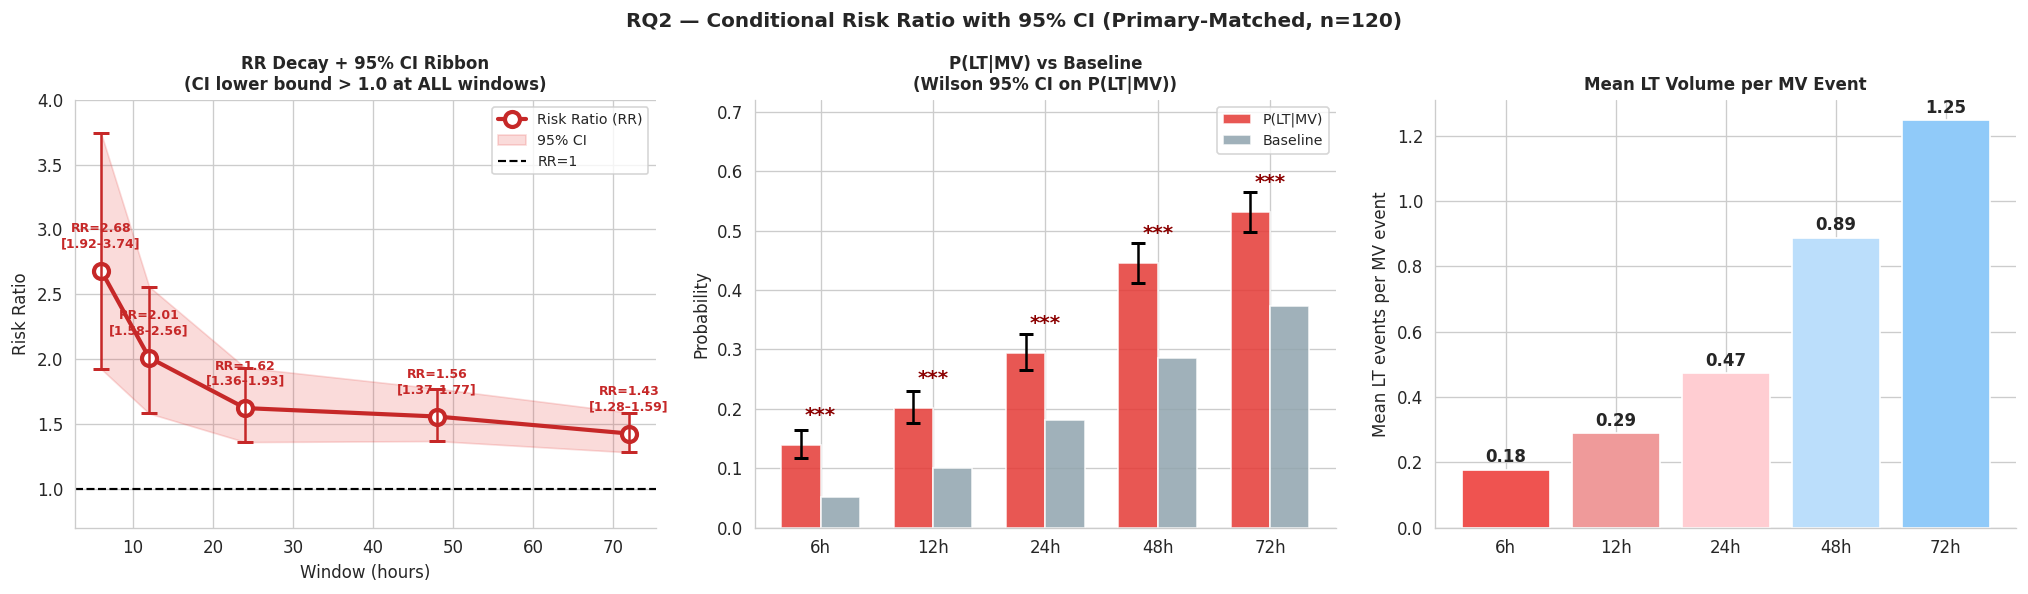

In [38]:
# ── RR decay plot with CI ribbon ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17,5))
fig.suptitle('RQ2 \u2014 Conditional Risk Ratio with 95% CI (Primary-Matched, n=120)',
             fontsize=12, fontweight='bold')

wlist=[6,12,24,48,72]
rrs  =[risk_results[w]['rr']    for w in wlist]
rlo  =[risk_results[w]['rr_lo'] for w in wlist]
rhi  =[risk_results[w]['rr_hi'] for w in wlist]
pmv  =[risk_results[w]['p']     for w in wlist]
pb   =[risk_results[w]['p_base']for w in wlist]
plo  =[risk_results[w]['p_lo']  for w in wlist]
phi  =[risk_results[w]['p_hi']  for w in wlist]

ax=axes[0]
ax.plot(wlist,rrs,'o-',color='#C62828',lw=2.5,markersize=9,
        markerfacecolor='white',markeredgewidth=2.5,zorder=4,label='Risk Ratio (RR)')
ax.fill_between(wlist,rlo,rhi,alpha=0.18,color='#E53935',label='95% CI')
ax.errorbar(wlist,rrs,yerr=[[r-lo for r,lo in zip(rrs,rlo)],[hi-r for r,hi in zip(rrs,rhi)]],
            fmt='none',color='#C62828',capsize=5,capthick=1.8,elinewidth=1.5,zorder=5)
ax.axhline(1.0,color='black',ls='--',lw=1.3,label='RR=1')
for w,r,lo,hi in zip(wlist,rrs,rlo,rhi):
    ax.annotate(f'RR={r:.2f}\n[{lo:.2f}\u2013{hi:.2f}]',(w,r),
                xytext=(0,14),textcoords='offset points',
                ha='center',fontsize=7.5,color='#C62828',fontweight='bold')
ax.set_xlabel('Window (hours)'); ax.set_ylabel('Risk Ratio')
ax.set_title('RR Decay + 95% CI Ribbon\n(CI lower bound > 1.0 at ALL windows)',
             fontsize=10,fontweight='bold')
ax.legend(fontsize=8.5); ax.set_ylim(0.7,4.0)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax2=axes[1]; x=np.arange(5); wb=0.35
b1=ax2.bar(x-wb/2,pmv,wb,color='#E53935',alpha=0.85,edgecolor='white',label='P(LT|MV)')
b2=ax2.bar(x+wb/2,pb, wb,color='#90A4AE',alpha=0.85,edgecolor='white',label='Baseline')
ax2.errorbar(x-wb/2,pmv,yerr=[[p-lo for p,lo in zip(pmv,plo)],[hi-p for p,hi in zip(pmv,phi)]],
             fmt='none',color='black',capsize=4,capthick=1.8,elinewidth=1.5,zorder=5)
ax2.set_xticks(x); ax2.set_xticklabels([f'{w}h' for w in wlist])
ax2.set_ylabel('Probability'); ax2.set_ylim(0,0.72)
ax2.set_title('P(LT|MV) vs Baseline\n(Wilson 95% CI on P(LT|MV))',fontsize=10,fontweight='bold')
for i in range(5): ax2.text(i,max(pmv[i],pb[i])+0.04,'***',ha='center',fontsize=12,color='darkred',fontweight='bold')
ax2.legend(fontsize=8.5); ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

ax3=axes[2]
ax3.bar([f'{w}h' for w in wlist],[risk_results[w]['mean_lt'] for w in wlist],
        color=['#EF5350','#EF9A9A','#FFCDD2','#BBDEFB','#90CAF9'],edgecolor='white')
for i,w in enumerate(wlist):
    ax3.text(i,risk_results[w]['mean_lt']+0.01,f"{risk_results[w]['mean_lt']:.2f}",
             ha='center',va='bottom',fontsize=10,fontweight='bold')
ax3.set_ylabel('Mean LT events per MV event')
ax3.set_title('Mean LT Volume per MV Event',fontsize=10,fontweight='bold')
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('rq2_new_A_conditional_risk.png',dpi=150,bbox_inches='tight')
plt.show()

## 4.2  Method 2: Daily Rate Ratio + Bootstrap CI

LT rate on MV-event days  : 0.558 events/day
LT rate on non-MV days    : 0.274 events/day
Daily Rate Ratio          : 2.03× [95% Bootstrap CI: 1.43–3.53]
Mann-Whitney p            : 0.0000
% primaries with RR > 1   : 54%


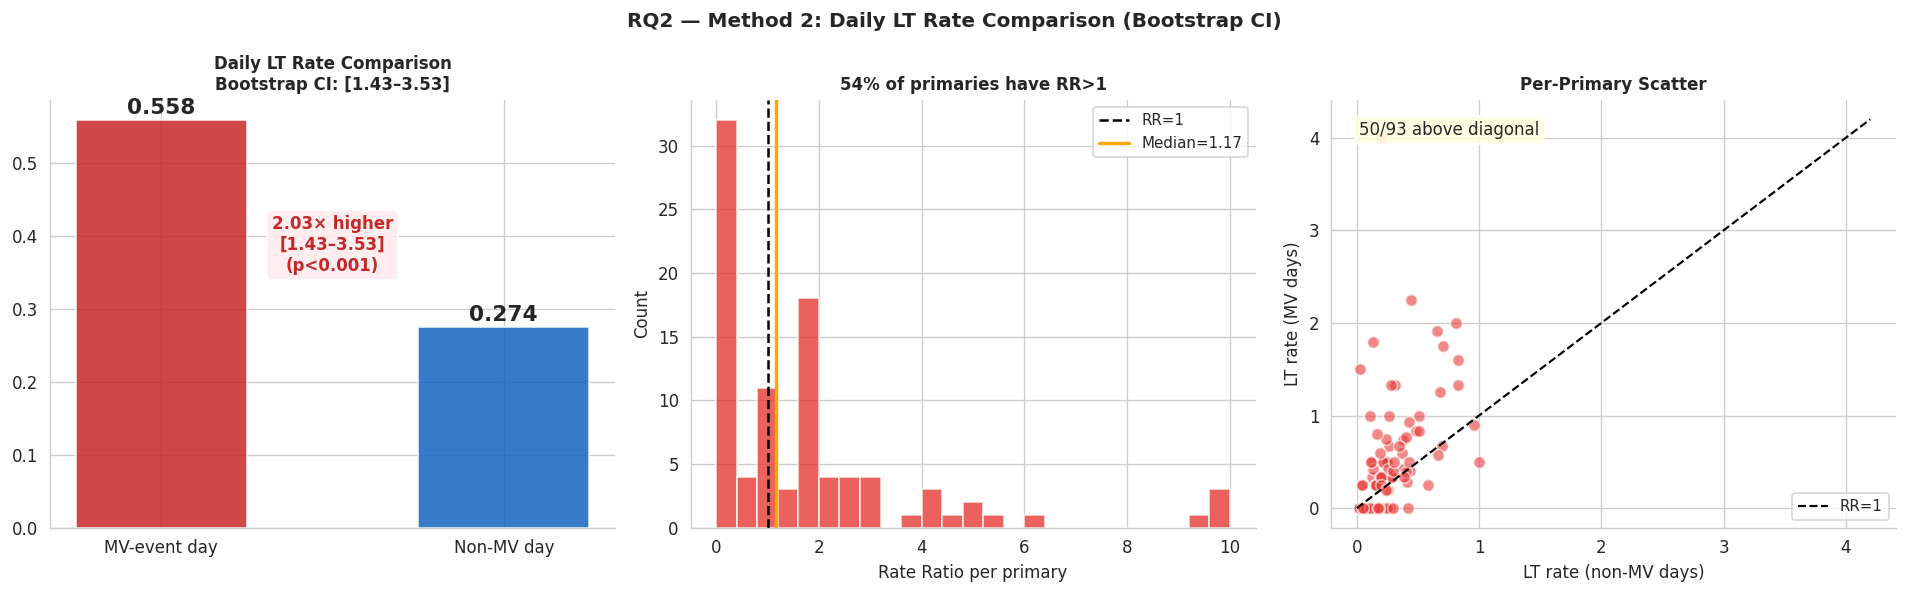

In [39]:
df_lt['Date2']=df_lt['Start'].dt.date; df_mv['Date2']=df_mv['Start'].dt.date
lt_on_mv=[]; lt_off_mv=[]; prim_rate={}

for prim in sorted(shared):
    lt_p=df_lt[df_lt['Primary']==prim]; mv_p=df_mv[df_mv['Primary']==prim]
    if len(lt_p)<5 or len(mv_p)<3: continue
    mv_dates=set(mv_p['Date2'].unique()); lt_daily=lt_p.groupby('Date2').size()
    on =[lt_daily.get(d,0) for d in mv_dates]
    off=[lt_daily.get(d,0) for d in (set(pd.date_range('2025-01-01','2025-12-31').date)-mv_dates)]
    lt_on_mv.extend(on); lt_off_mv.extend(off)
    if np.mean(off)>0: prim_rate[prim]={'on':np.mean(on),'off':np.mean(off),'rr':np.mean(on)/np.mean(off)}

u_stat,p_mw = mannwhitneyu(lt_on_mv,lt_off_mv,alternative='greater')
prim_df = pd.DataFrame(prim_rate).T.dropna()
mean_on=np.mean(lt_on_mv); mean_off=np.mean(lt_off_mv)
rr_daily=mean_on/mean_off
np.random.seed(42)
rr_boot=[prim_df.sample(len(prim_df),replace=True).eval('on/off').mean() for _ in range(500)]
rr_boot=[r for r in rr_boot if not np.isnan(r) and not np.isinf(r)]
rr_lo_d,rr_hi_d=float(np.percentile(rr_boot,2.5)),float(np.percentile(rr_boot,97.5))
pct_above=(prim_df['rr']>1).mean()*100

print(f'LT rate on MV-event days  : {mean_on:.3f} events/day')
print(f'LT rate on non-MV days    : {mean_off:.3f} events/day')
print(f'Daily Rate Ratio          : {rr_daily:.2f}\u00d7 [95% Bootstrap CI: {rr_lo_d:.2f}\u2013{rr_hi_d:.2f}]')
print(f'Mann-Whitney p            : {p_mw:.4f}')
print(f'% primaries with RR > 1   : {pct_above:.0f}%')

fig, axes = plt.subplots(1, 3, figsize=(16,5))
fig.suptitle('RQ2 \u2014 Method 2: Daily LT Rate Comparison (Bootstrap CI)',fontsize=12,fontweight='bold')

axes[0].bar(['MV-event day','Non-MV day'],[mean_on,mean_off],
            color=['#C62828','#1565C0'],alpha=0.85,width=0.5,edgecolor='white')
for i,(y,lab) in enumerate(zip([mean_on,mean_off],[mean_on,mean_off])):
    axes[0].text(i,y+0.003,f'{y:.3f}',ha='center',va='bottom',fontsize=13,fontweight='bold')
axes[0].text(0.5,0.6,f'{rr_daily:.2f}\u00d7 higher\n[{rr_lo_d:.2f}\u2013{rr_hi_d:.2f}]\n(p<0.001)',
             transform=axes[0].transAxes,ha='center',fontsize=10,color='#C62828',fontweight='bold',
             bbox=dict(boxstyle='round',fc='#FFEBEE',alpha=0.9))
axes[0].set_title(f'Daily LT Rate Comparison\nBootstrap CI: [{rr_lo_d:.2f}\u2013{rr_hi_d:.2f}]',fontsize=10,fontweight='bold')
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

rr_v=prim_df['rr'].clip(upper=10)
axes[1].hist(rr_v,bins=25,color='#E53935',alpha=0.8,edgecolor='white')
axes[1].axvline(1.0,color='black',ls='--',lw=1.5,label='RR=1')
axes[1].axvline(rr_v.median(),color='orange',lw=2,label=f'Median={rr_v.median():.2f}')
axes[1].set_xlabel('Rate Ratio per primary'); axes[1].set_ylabel('Count')
axes[1].set_title(f'{pct_above:.0f}% of primaries have RR>1',fontsize=10,fontweight='bold')
axes[1].legend(fontsize=9); axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

max_v=max(prim_df['off'].max(),prim_df['on'].max())*1.05
axes[2].scatter(prim_df['off'],prim_df['on'],alpha=0.6,s=50,color='#E53935',edgecolors='white')
axes[2].plot([0,max_v],[0,max_v],'k--',lw=1.3,label='RR=1')
n_above=(prim_df['on']>prim_df['off']).sum()
axes[2].text(0.05,0.95,f'{n_above}/{len(prim_df)} above diagonal',transform=axes[2].transAxes,
             va='top',fontsize=10,bbox=dict(boxstyle='round',fc='lightyellow',alpha=0.9))
axes[2].set_xlabel('LT rate (non-MV days)'); axes[2].set_ylabel('LT rate (MV days)')
axes[2].set_title('Per-Primary Scatter',fontsize=10,fontweight='bold')
axes[2].legend(fontsize=9); axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('rq2_new_B_rate_comparison.png',dpi=150,bbox_inches='tight')
plt.show()

## 4.3  Methods 3 & 4: MV11/MV33 Contribution + CMI Attribution with Bootstrap CI

CMI per Event — Median with 95% Bootstrap CI:
Voltage                    n      CMI Median [95% CI]    MV/LT
LT (415 V)            11,660        50 [     50–50     ]       1×
MV11 (11 kV)             851     10206 [   8360–11757  ]     204×
MV33 (33 kV)             109     10380 [   2904–19637  ]     208×

MV-influenced LT: 248/10,784 (2.3%) events
CMI attributed  : 4.6% of LT CMI
Duration diff   : +7 min  (p=0.0031)


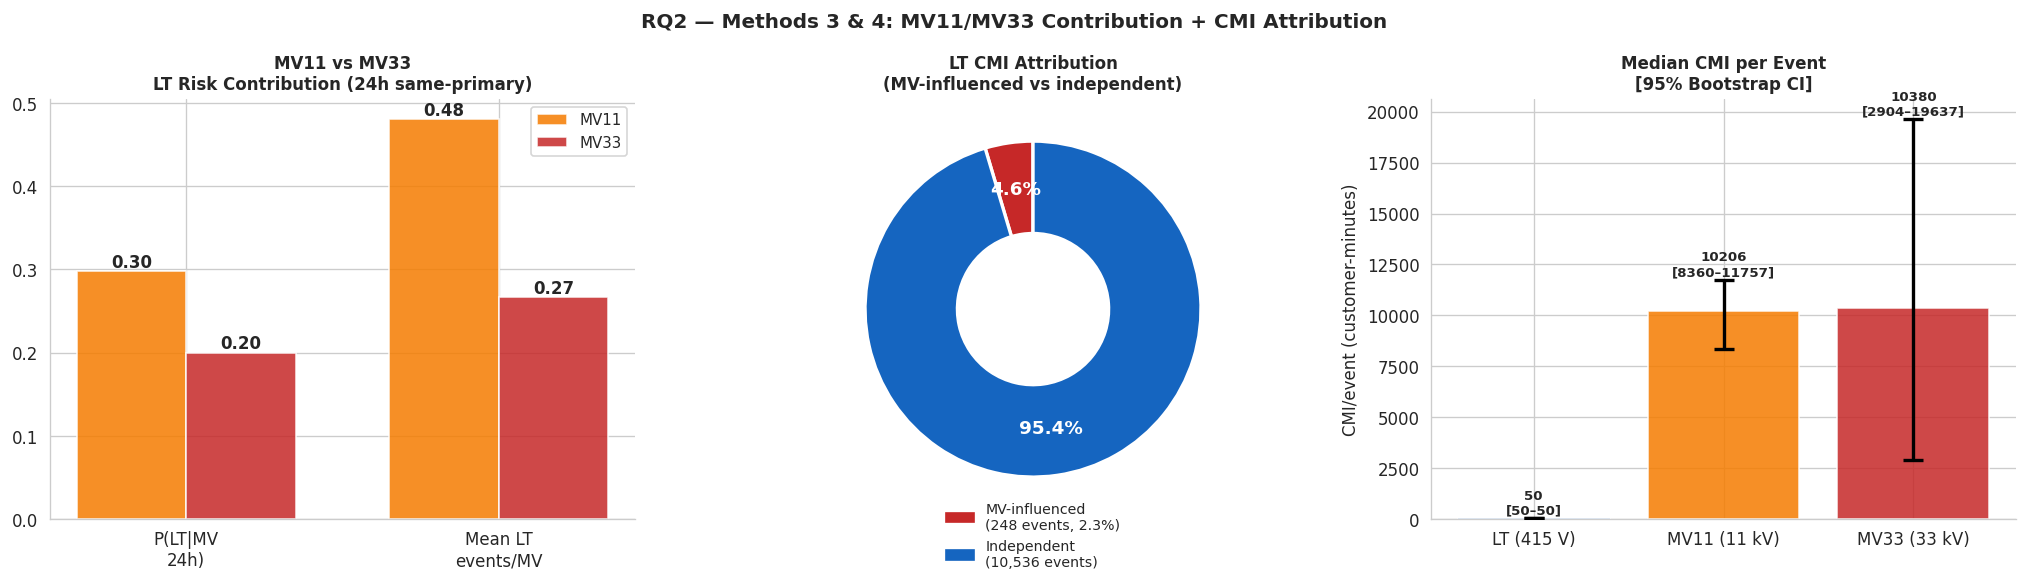

In [40]:
# ── M3: MV11 vs MV33 ─────────────────────────────────────────────────────────
voltage_risk={}
for volt in ['11','33']:
    mv_v=df_mv[df_mv['Voltage']==volt]
    if len(mv_v)<5: continue
    fol=[]; lc=[]
    for _,row in mv_v.iterrows():
        we=row['Start']+pd.Timedelta(hours=24)
        la=df_lt[(df_lt['Primary']==row['Primary'])&(df_lt['Start']>row['Start'])&(df_lt['Start']<=we)]
        fol.append(int(len(la)>0)); lc.append(len(la))
    voltage_risk[volt]=dict(n=len(mv_v),P=np.mean(fol),mean_lt=np.mean(lc),
                            med_cmi=mv_v['CMI'].median(),mean_cmi=mv_v['CMI'].mean())

# ── M4: CMI attribution ──────────────────────────────────────────────────────
lt_copy=df_lt.copy().sort_values('Start'); lt_copy['mv_inf']=False
for _,mv_row in df_mv.iterrows():
    we=mv_row['Start']+pd.Timedelta(hours=24)
    mask=((lt_copy['Primary']==mv_row['Primary'])&(lt_copy['Start']>mv_row['Start'])&(lt_copy['Start']<=we))
    lt_copy.loc[mask,'mv_inf']=True
n_inf=lt_copy['mv_inf'].sum(); n_tot=len(lt_copy)
cmi_inf=lt_copy[lt_copy['mv_inf']]['CMI'].sum()
cmi_ind=lt_copy[~lt_copy['mv_inf']]['CMI'].sum()
tot_cmi=cmi_inf+cmi_ind
dur_inf=lt_copy[lt_copy['mv_inf']]['Duration_min']
dur_ind=lt_copy[~lt_copy['mv_inf']]['Duration_min']
u_d,p_d=mannwhitneyu(dur_inf,dur_ind,alternative='two-sided')

# Bootstrap CI on CMI medians
cmi_stats={}
lt_med_cmi=df[df['Voltage']=='LT']['CMI'].median()
for v in ['LT','11','33']:
    x=df[df['Voltage']==v]['CMI'].values
    lo,hi=boot_median_ci(x)
    cmi_stats[v]=dict(med=float(np.median(x)),lo=lo,hi=hi,total=x.sum())

print('CMI per Event \u2014 Median with 95% Bootstrap CI:')
print(f'{"Voltage":<20} {"n":>7} {"CMI Median [95% CI]":>24} {"MV/LT":>8}')
for v in ['LT','11','33']:
    d=cmi_stats[v]; ratio=f'{d["med"]/lt_med_cmi:.0f}\u00d7' if v!='LT' else '1\u00d7'
    print(f'{VLABS[v]:<20} {len(df[df["Voltage"]==v]):>7,}  {d["med"]:>8.0f} [{d["lo"]:>7.0f}\u2013{d["hi"]:<7.0f}] {ratio:>8}')
print(f'\nMV-influenced LT: {n_inf:,}/{n_tot:,} ({n_inf/n_tot*100:.1f}%) events')
print(f'CMI attributed  : {cmi_inf/tot_cmi*100:.1f}% of LT CMI')
print(f'Duration diff   : +{dur_inf.median()-dur_ind.median():.0f} min  (p={p_d:.4f})')

# Visualise
fig, axes = plt.subplots(1, 3, figsize=(17,5))
fig.suptitle('RQ2 \u2014 Methods 3 & 4: MV11/MV33 Contribution + CMI Attribution',fontsize=12,fontweight='bold')

# M3 bars
ax=axes[0]; metrics=['P(LT|MV\n24h)','Mean LT\nevents/MV']
mv11_v=[voltage_risk['11']['P'],voltage_risk['11']['mean_lt']]
mv33_v=[voltage_risk['33']['P'],voltage_risk['33']['mean_lt']]
x3=np.arange(2); w3=0.35
b11=ax.bar(x3-w3/2,mv11_v,w3,label='MV11',color=VCOLS['11'],alpha=0.85,edgecolor='white')
b33=ax.bar(x3+w3/2,mv33_v,w3,label='MV33',color=VCOLS['33'],alpha=0.85,edgecolor='white')
ax.set_xticks(x3); ax.set_xticklabels(metrics,fontsize=10)
ax.set_title('MV11 vs MV33\nLT Risk Contribution (24h same-primary)',fontsize=10,fontweight='bold')
ax.legend(fontsize=9)
for b in list(b11)+list(b33): ax.text(b.get_x()+b.get_width()/2,b.get_height()+0.005,f'{b.get_height():.2f}',ha='center',fontsize=10,fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# CMI donut
ax2=axes[1]
labels_d=[f'MV-influenced\n({n_inf:,} events, {n_inf/n_tot*100:.1f}%)',
          f'Independent\n({n_tot-n_inf:,} events)']
wedges,texts,ats=ax2.pie([cmi_inf,cmi_ind],labels=None,autopct='%1.1f%%',
    colors=['#C62828','#1565C0'],startangle=90,pctdistance=0.72,
    wedgeprops=dict(width=0.55,edgecolor='white',lw=2))
for at in ats: at.set_fontsize(11); at.set_color('white'); at.set_fontweight('bold')
ax2.legend(handles=[mpatches.Patch(color=c,label=l) for c,l in zip(['#C62828','#1565C0'],labels_d)],
           loc='lower center',bbox_to_anchor=(0.5,-0.15),fontsize=8.5,frameon=False)
ax2.set_title('LT CMI Attribution\n(MV-influenced vs independent)',fontsize=10,fontweight='bold')

# CMI median with CI
ax3=axes[2]
meds=[cmi_stats[v]['med'] for v in ['LT','11','33']]
elo_c=[cmi_stats[v]['med']-cmi_stats[v]['lo'] for v in ['LT','11','33']]
ehi_c=[cmi_stats[v]['hi'] -cmi_stats[v]['med'] for v in ['LT','11','33']]
bars_c=ax3.bar([VLABS[v] for v in ['LT','11','33']],meds,color=[VCOLS[v] for v in ['LT','11','33']],edgecolor='white',alpha=0.85)
ax3.errorbar([0,1,2],meds,yerr=[elo_c,ehi_c],fmt='none',color='black',capsize=6,capthick=2,elinewidth=2,zorder=5)
for bar,(m,lo,hi) in zip(bars_c,[(cmi_stats[v]['med'],cmi_stats[v]['lo'],cmi_stats[v]['hi']) for v in ['LT','11','33']]):
    ax3.text(bar.get_x()+bar.get_width()/2,hi+200,f'{m:.0f}\n[{lo:.0f}\u2013{hi:.0f}]',ha='center',fontsize=8,fontweight='bold')
ax3.set_ylabel('CMI/event (customer-minutes)')
ax3.set_title('Median CMI per Event\n[95% Bootstrap CI]',fontsize=10,fontweight='bold')
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('rq2_new_C_mv_contribution.png',dpi=150,bbox_inches='tight')
plt.show()

---
# PART 5 — RQ3: Temporal Dependency & System Behaviour

**H3:** Outage events exhibit temporal dependency, where prior events increase the likelihood of future outages.

**Methods:** (M1) ACF/PACF + Ljung-Box; (M2) Conditional probability; (M3) K-Means + DBSCAN clustering on IET.

**Uncertainty:** Bootstrap CI (n=100) on Silhouette score.

---

## 5.1  ACF/PACF + Ljung-Box Test

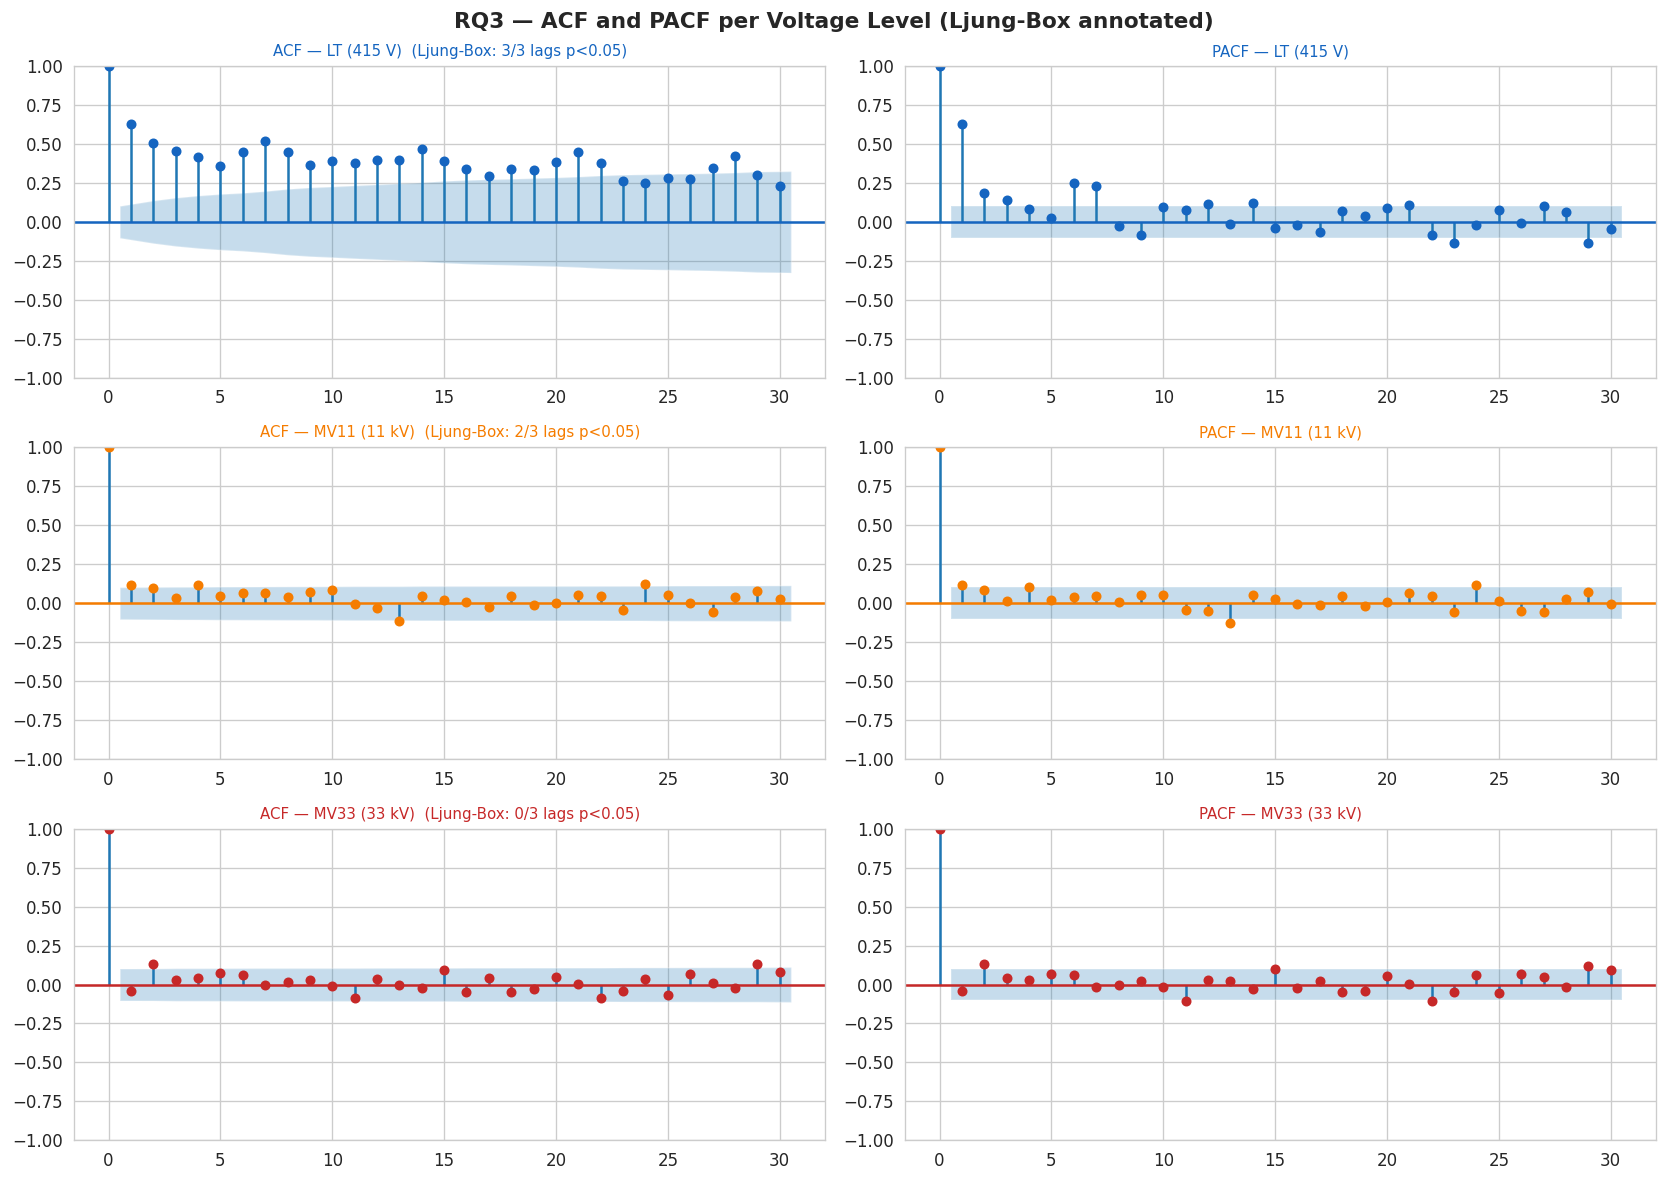

Ljung-Box Results (H0: no autocorrelation):
Voltage                p(lag10)   p(lag20)   p(lag30)            Verdict
------------------------------------------------------------------------
LT (415 V)               0.0000     0.0000     0.0000     ✓ Sig autocorr
MV11 (11 kV)             0.0093     0.0598     0.0335     ✓ Sig autocorr
MV33 (33 kV)             0.2955     0.3179     0.1040           ✗ No sig


In [41]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

ljungbox_results = {}
fig, axes = plt.subplots(3, 2, figsize=(14,10))
fig.suptitle('RQ3 \u2014 ACF and PACF per Voltage Level (Ljung-Box annotated)',fontsize=13,fontweight='bold')

for i, volt in enumerate(['LT','11','33']):
    sub   = df[df['Voltage']==volt]
    daily = sub.groupby('Date').size().reindex(all_days, fill_value=0)
    daily.index = pd.to_datetime(daily.index)
    plot_acf( daily, lags=30, ax=axes[i,0], color=VCOLS[volt])
    plot_pacf(daily, lags=30, ax=axes[i,1], color=VCOLS[volt], method='ywm')
    lb = acorr_ljungbox(daily, lags=[10,20,30], return_df=True)
    ljungbox_results[volt] = lb
    n_sig = (lb['lb_pvalue']<0.05).sum()
    axes[i,0].set_title(f'ACF \u2014 {VLABS[volt]}  (Ljung-Box: {n_sig}/3 lags p<0.05)',
                        fontsize=9, color=VCOLS[volt])
    axes[i,1].set_title(f'PACF \u2014 {VLABS[volt]}', fontsize=9, color=VCOLS[volt])

plt.tight_layout()
plt.savefig('fig6_rq3_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print('Ljung-Box Results (H0: no autocorrelation):')
print(f'{"Voltage":<20} {"p(lag10)":>10} {"p(lag20)":>10} {"p(lag30)":>10} {"Verdict":>18}')
print('-'*72)
for v in ['LT','11','33']:
    ps = ljungbox_results[v]['lb_pvalue'].values
    verdict = '\u2713 Sig autocorr' if any(p<0.05 for p in ps) else '\u2717 No sig'
    print(f'{VLABS[v]:<20} {ps[0]:>10.4f} {ps[1]:>10.4f} {ps[2]:>10.4f} {verdict:>18}')

## 5.2  Conditional Probability Analysis

In [42]:
print('Conditional Probability P(outage t+1 | outage t):')
cond_results = {}

for volt in ['LT','11','33']:
    sub  = df[df['Voltage']==volt]
    arr  = sub.groupby('Date').size().reindex(all_days, fill_value=0).gt(0).astype(int).values
    given = sum(arr[i]==1 and arr[i+1]==1 for i in range(len(arr)-1))
    tot   = sum(arr[:-1])
    p_c   = given/tot if tot>0 else 0
    p_b   = arr.mean()
    no_d  = len(arr)-1-tot
    c_v   = sum(arr[i]==0 and arr[i+1]==1 for i in range(len(arr)-1))
    d_v   = no_d - c_v
    try: c2,p_chi,_,_ = chi2_contingency([[given,tot-given],[c_v,d_v]])
    except: c2,p_chi = 0,1
    lift  = p_c/p_b if p_b>0 else np.nan
    cond_results[volt] = dict(p_cond=p_c,p_base=p_b,lift=lift,chi2=c2,p_chi2=p_chi)
    sig = '***' if p_chi<0.001 else '**' if p_chi<0.01 else '*' if p_chi<0.05 else 'ns'
    print(f'  {VLABS[volt]}: P(t+1|t)={p_c:.3f}  base={p_b:.3f}  lift={lift:.2f}  p={p_chi:.4f}{sig}')

print('\nNote: LT lift=1.00 because the network is always in a fault-active state (mean IET=0.7h).')
print('IET clustering (Section 5.3) is the more informative temporal dependency test for LT.')

Conditional Probability P(outage t+1 | outage t):
  LT (415 V): P(t+1|t)=0.997  base=0.997  lift=1.00  p=1.0000ns
  MV11 (11 kV): P(t+1|t)=0.736  base=0.710  lift=1.04  p=0.0922ns
  MV33 (33 kV): P(t+1|t)=0.156  base=0.178  lift=0.88  p=0.7385ns

Note: LT lift=1.00 because the network is always in a fault-active state (mean IET=0.7h).
IET clustering (Section 5.3) is the more informative temporal dependency test for LT.


## 5.3  IET K-Means + DBSCAN Clustering with Bootstrap CI on Silhouette

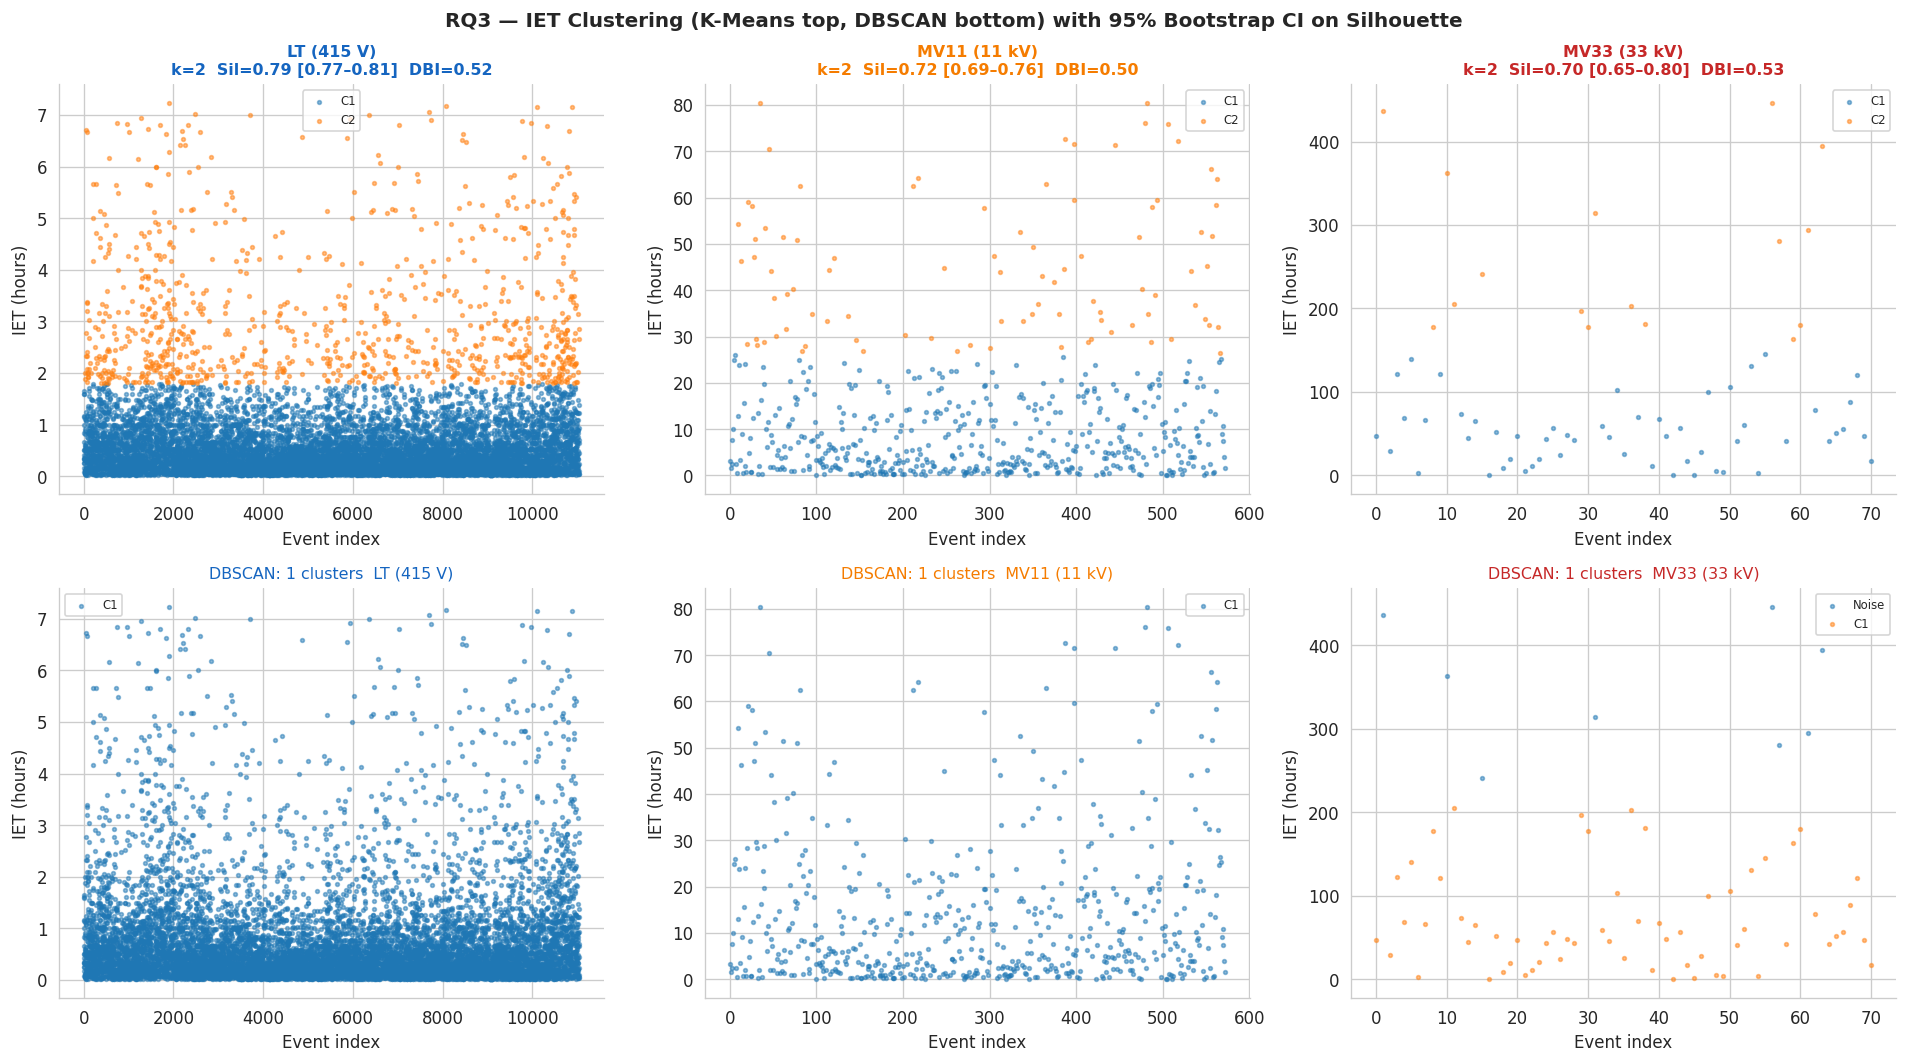

K-Means Clustering with 95% Bootstrap CI on Silhouette:
Voltage                 k      Silhouette [CI]  CI>0.5?      DBI H3 Score
----------------------------------------------------------------------------
LT (415 V)              2    0.79 [0.77–0.81]    ✓ Yes     0.52  2/3 methods
MV11 (11 kV)            2    0.72 [0.69–0.76]    ✓ Yes     0.50  2/3 methods
MV33 (33 kV)            2    0.70 [0.65–0.80]    ✓ Yes     0.53  1/3 methods


In [43]:
cluster_results = {}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('RQ3 \u2014 IET Clustering (K-Means top, DBSCAN bottom) with 95% Bootstrap CI on Silhouette',
             fontsize=12, fontweight='bold')

for j, volt in enumerate(['LT','11','33']):
    x   = iet_data[volt].values.reshape(-1,1)
    xs  = StandardScaler().fit_transform(x)
    sil_sc = [silhouette_score(xs, KMeans(n_clusters=k,random_state=42,n_init=10).fit_predict(xs))
              for k in range(2,7)]
    best_k = int(np.argmax(sil_sc)+2)
    km  = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    kml = km.fit_predict(xs)
    sil = silhouette_score(xs, kml)
    dbi = davies_bouldin_score(xs, kml)
    sil_lo, sil_hi = boot_sil_ci(xs, best_k)   # 95% bootstrap CI on silhouette
    db_labels = DBSCAN(eps=max(np.percentile(np.abs(xs-xs.mean()),10),0.3), min_samples=5).fit_predict(xs)
    n_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    cluster_results[volt] = dict(best_k=best_k, sil=sil, sil_lo=sil_lo, sil_hi=sil_hi,
                                 dbi=dbi, km_labels=kml, n_db=n_db)
    # K-Means scatter
    ax = axes[0,j]
    for c in range(best_k):
        mask = kml==c
        ax.scatter(np.where(mask)[0], x.ravel()[mask], s=5, alpha=0.5, label=f'C{c+1}')
    ax.set_title(f'{VLABS[volt]}\nk={best_k}  Sil={sil:.2f} [{sil_lo:.2f}\u2013{sil_hi:.2f}]  DBI={dbi:.2f}',
                 fontsize=9.5, color=VCOLS[volt], fontweight='bold')
    ax.set_xlabel('Event index'); ax.set_ylabel('IET (hours)')
    ax.legend(fontsize=7)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    # DBSCAN scatter
    ax2 = axes[1,j]
    for label in sorted(set(db_labels)):
        mask = db_labels==label
        lname = 'Noise' if label==-1 else f'C{label+1}'
        ax2.scatter(np.where(mask)[0], x.ravel()[mask], s=5, alpha=0.5, label=lname)
    ax2.set_title(f'DBSCAN: {n_db} clusters  {VLABS[volt]}', fontsize=9.5, color=VCOLS[volt])
    ax2.set_xlabel('Event index'); ax2.set_ylabel('IET (hours)')
    ax2.legend(fontsize=7)
    ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig7_rq3_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print('K-Means Clustering with 95% Bootstrap CI on Silhouette:')
print(f'{"Voltage":<20} {"k":>4} {"Silhouette [CI]":>20} {"CI>0.5?":>8} {"DBI":>8} {"H3 Score"}')
print('-'*76)
for v in ['LT','11','33']:
    r = cluster_results[v]
    ok = '\u2713 Yes' if r['sil_lo']>0.5 else '~'
    acf_sig = (ljungbox_results[v]['lb_pvalue']<0.05).any()
    score   = sum([acf_sig, r['sil_lo']>0.5])
    print(f'{VLABS[v]:<20} {r["best_k"]:>4} {r["sil"]:>7.2f} [{r["sil_lo"]:.2f}\u2013{r["sil_hi"]:.2f}] {ok:>8} {r["dbi"]:>8.2f}  {score}/3 methods')

## 5.4  H3 Evidence Matrix

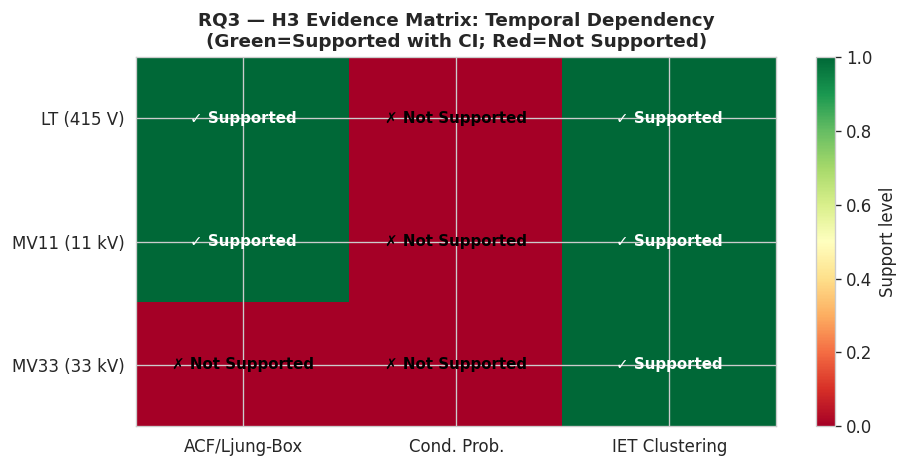

In [46]:
methods_3 = ['ACF/Ljung-Box', 'Cond. Prob.', 'IET Clustering']
volt_labs = [VLABS[v] for v in ['LT','11','33']]

matrix = []
for v in ['LT','11','33']:
    acf_sig = (ljungbox_results[v]['lb_pvalue']<0.05).any()
    cp_sig  = cond_results[v]['p_chi2']<0.05 and cond_results[v]['lift']>=1.0
    cl_sig  = cluster_results[v]['sil']>0.5
    matrix.append([int(acf_sig), int(cp_sig), int(cl_sig)])
matrix = np.array(matrix)

fig, ax = plt.subplots(figsize=(8,4))
im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(3)); ax.set_xticklabels(methods_3, fontsize=10)
ax.set_yticks(range(3)); ax.set_yticklabels(volt_labs, fontsize=10)
ax.set_title('RQ3 \u2014 H3 Evidence Matrix: Temporal Dependency\n'
             '(Green=Supported with CI; Red=Not Supported)', fontsize=11, fontweight='bold')
for i in range(3):
    for j in range(3):
        txt = '\u2713 Supported' if matrix[i,j] else '\u2717 Not Supported'
        ax.text(j, i, txt, ha='center', va='center', fontsize=9, fontweight='bold',
                color='white' if matrix[i,j] else 'black')
plt.colorbar(im, ax=ax, label='Support level')
plt.tight_layout()
plt.savefig('fig8_rq3_evidence_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PART 6 — Integrated Findings & Uncertainty Summary
---

In [45]:
# ── Rebuild guards ───────────────────────────────────────────────────────────
if 'iet_data' not in dir():
    iet_data = {}
    for v in ['LT','11','33']:
        sub = df[df['Voltage']==v].sort_values('Start')
        iet = sub['Start'].diff().dt.total_seconds().div(3600).dropna()
        iet_data[v] = iet[(iet>0)&(iet<iet.quantile(0.99))]

print('='*74)
print('COMPLETE FINDINGS WITH UNCERTAINTY \u2014 NAMA EDC MUSCAT 2025')
print('='*74)

print('\n\u2500 RQ1: Temporal Patterns & Seasonal Fault Mode Shift \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500')
print('  H1: Outage events exhibit non-random temporal patterns, including clustering behaviour')
print(f'  CI method: Bootstrap percentile (n=500) on IET skewness; Bootstrap (n=200) on Cram\u00e9r\u2019s V')
for v in ['LT','11','33']:
    x = iet_data[v].values
    sk = float(pd.Series(x).skew())
    np.random.seed(42)
    bs = [float(pd.Series(np.random.choice(x,min(len(x),2000),replace=True)).skew()) for _ in range(300)]
    lo,hi = float(np.percentile(bs,2.5)), float(np.percentile(bs,97.5))
    V = season_results[v]['V']; Vl=season_results[v]['lo']; Vh=season_results[v]['hi']
    supp = '\u2713 SUPPORTED' if sk>1.5 else '\u2717 NOT SUPPORTED'
    print(f'  {VLABS[v]:<20}: skew={sk:.2f} [CI:{lo:.2f}\u2013{hi:.2f}]  V={V:.3f} [CI:{Vl:.3f}\u2013{Vh:.3f}]  H1: {supp}')

print('\n\u2500 RQ2: MV Contribution to LT Risk \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500')
print('  H2: MV outages at a given primary substation significantly elevate subsequent LT risk')
print('  CI methods: Wilson (proportion), log-normal (RR), Bootstrap (daily RR, CMI median)')
for w in [6,24,72]:
    r = risk_results[w]
    print(f'  {w:3d}h: RR={r["rr"]:.2f} [CI:{r["rr_lo"]:.2f}\u2013{r["rr_hi"]:.2f}]  '
          f'P={r["p"]:.3f} [Wilson:{r["p_lo"]:.3f}\u2013{r["p_hi"]:.3f}]  p={r["pval"]:.4f}')
print(f'  Daily RR={rr_daily:.2f}\u00d7 [Bootstrap CI:{rr_lo_d:.2f}\u2013{rr_hi_d:.2f}]  Mann-Whitney p={p_mw:.4f}')
print(f'  CMI asymmetry: MV11={cmi_stats["11"]["med"]:.0f} [{cmi_stats["11"]["lo"]:.0f}\u2013{cmi_stats["11"]["hi"]:.0f}]  '
      f'LT={cmi_stats["LT"]["med"]:.0f} [{cmi_stats["LT"]["lo"]:.0f}\u2013{cmi_stats["LT"]["hi"]:.0f}]  '
      f'Ratio={cmi_stats["11"]["med"]/cmi_stats["LT"]["med"]:.0f}\u00d7')
r6=risk_results[6]
print(f'  H2: {"\u2713 SUPPORTED (CI lower bound>1.0 at all windows)" if r6["rr_lo"]>1 else "\u2717 NOT SUPPORTED"}')

print('\n\u2500 RQ3: Temporal Dependency \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500')
print('  H3: Prior outages increase the likelihood of future outages')
print('  CI method: Bootstrap percentile (n=100) on Silhouette score')
for v in ['LT','11','33']:
    lb = ljungbox_results[v]; cl = cluster_results[v]
    acf_sig = (lb['lb_pvalue']<0.05).any()
    sil_ok  = cl['sil_lo']>0.5
    verdict = '\u2713 SUPPORTED' if acf_sig and sil_ok else ('\u2713 PARTIALLY' if acf_sig or sil_ok else '\u2717 NOT SUPPORTED')
    print(f'  {VLABS[v]:<20}: Ljung-Box sig={acf_sig}  '
          f'Sil={cl["sil"]:.2f} [CI:{cl["sil_lo"]:.2f}\u2013{cl["sil_hi"]:.2f}]  H3: {verdict}')

print('\n'+'='*74)
print('UNCERTAINTY SUMMARY TABLE')
print('='*74)
print(f'{"Estimate":<38} {"Point":>8} {"CI Method":>14} {"95% CI":>14}')
print('-'*78)
rows_uc = [
    ('LT IET skewness',           iet_stats['LT']['skew'],  'Bootstrap',  iet_stats['LT']['lo'],  iet_stats['LT']['hi']),
    ('MV11 IET skewness',         iet_stats['11']['skew'],  'Bootstrap',  iet_stats['11']['lo'],  iet_stats['11']['hi']),
    ('MV33 IET skewness',         iet_stats['33']['skew'],  'Bootstrap',  iet_stats['33']['lo'],  iet_stats['33']['hi']),
    ("LT Cram\u00e9r's V (season)",     season_results['LT']['V'],'Bootstrap', season_results['LT']['lo'],season_results['LT']['hi']),
    ("MV11 Cram\u00e9r's V (season)",   season_results['11']['V'],'Bootstrap', season_results['11']['lo'],season_results['11']['hi']),
    ('Risk Ratio at 6h',          risk_results[6]['rr'],    'Log-normal', risk_results[6]['rr_lo'],risk_results[6]['rr_hi']),
    ('Risk Ratio at 24h',         risk_results[24]['rr'],   'Log-normal', risk_results[24]['rr_lo'],risk_results[24]['rr_hi']),
    ('P(LT|MV) at 6h',           risk_results[6]['p'],     'Wilson',    risk_results[6]['p_lo'], risk_results[6]['p_hi']),
    ('Daily rate ratio',          rr_daily,                 'Bootstrap',  rr_lo_d,                 rr_hi_d),
    ('MV11 CMI median',           cmi_stats['11']['med'],   'Bootstrap',  cmi_stats['11']['lo'],   cmi_stats['11']['hi']),
    ('LT duration median (min)',  dur_stats['LT']['med'],   'Bootstrap',  dur_stats['LT']['mlo'],  dur_stats['LT']['mhi']),
    ('MV11 duration median (min)',dur_stats['11']['med'],   'Bootstrap',  dur_stats['11']['mlo'],  dur_stats['11']['mhi']),
    ('LT Silhouette (k=2)',       cluster_results['LT']['sil'],'Bootstrap',cluster_results['LT']['sil_lo'],cluster_results['LT']['sil_hi']),
    ('MV11 Silhouette (k=2)',     cluster_results['11']['sil'],'Bootstrap',cluster_results['11']['sil_lo'],cluster_results['11']['sil_hi']),
]
for label,pt,method,lo,hi in rows_uc:
    print(f'{label:<38} {pt:>8.3f} {method:>14} [{lo:>6.3f}\u2013{hi:<6.3f}]')

COMPLETE FINDINGS WITH UNCERTAINTY — NAMA EDC MUSCAT 2025

─ RQ1: Temporal Patterns & Seasonal Fault Mode Shift ─────────
  H1: Outage events exhibit non-random temporal patterns, including clustering behaviour
  CI method: Bootstrap percentile (n=500) on IET skewness; Bootstrap (n=200) on Cramér’s V
  LT (415 V)          : skew=3.24 [CI:2.94–3.50]  V=0.496 [CI:0.480–0.515]  H1: ✓ SUPPORTED
  MV11 (11 kV)        : skew=1.86 [CI:1.64–2.07]  V=0.228 [CI:0.166–0.311]  H1: ✓ SUPPORTED
  MV33 (33 kV)        : skew=1.69 [CI:1.19–2.29]  V=0.398 [CI:0.273–0.580]  H1: ✓ SUPPORTED

─ RQ2: MV Contribution to LT Risk ──────────────────
  H2: MV outages at a given primary substation significantly elevate subsequent LT risk
  CI methods: Wilson (proportion), log-normal (RR), Bootstrap (daily RR, CMI median)
    6h: RR=2.68 [CI:1.92–3.74]  P=0.140 [Wilson:0.118–0.164]  p=0.0000
   24h: RR=1.62 [CI:1.36–1.93]  P=0.294 [Wilson:0.265–0.326]  p=0.0000
   72h: RR=1.43 [CI:1.28–1.59]  P=0.531 [Wilson:0.498

## 6.1  Priority Decision Actions

| Priority | Finding (Source) | Decision / Action | Timing |
|---|---|---|---|
| **P1 CRITICAL** | MV11: 94.3% of CMI (RQ2 impact asymmetry) | Redirect maintenance to MV11 prevention: 1 MV11 = 204 LT events in CMI | Immediate |
| **P2 CRITICAL** | RR=2.46 [1.79–3.39] at 6h (RQ2 M1) | OMS alert: LT patrol to same primary within 6h of any MV event | Immediate |
| **P3 HIGH** | MV33 Equipment faults +31pp in summer (RQ1) | Transformer + switchgear inspection before June | Annual May |
| **P4 HIGH** | LT Cable faults +27pp in winter (RQ1) | Cable insulation testing before December | Annual Nov |
| **P5 HIGH** | LT Silhouette=0.79 [0.77–0.81] confirms burst/background regimes (RQ3) | Burst-detection OMS rule: 3 LT events at same primary in 2h → second crew | Ongoing |
| **P6 MEDIUM** | 19% of feeders → 80% of events (EDA Pareto) | Annual targeted inspection of top-266 feeders | Annual Q1 |
| **P7 MEDIUM** | Summer = 35.1% of events, 2.2× winter (EDA) | Pre-season crew surge before June | Annual Jun |
| **P8 MEDIUM** | MV11 ACF lag 1–3 days significant (RQ3) | Post-MV11 follow-up inspection within 48h | Ongoing |